# Data and Study Design for Bayesian Production Monitoring

The annotated cutting path is the observation unit; paths are nested within experiments from two machine domains. This notebook examines sample composition, label integrity, acquisition timing and process conditions, then defines experiment-disjoint splits. No feature selection or model fitting is performed.


In [1]:
# Imports and plotting configuration
from __future__ import annotations
from collections.abc import Mapping, Sequence
import gc
import os
import random
import re
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.container import BarContainer
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import Markdown, display

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (CWD, *CWD.parents)
    if (path / "notebooks").is_dir() and (path / "dataset").is_dir())
SEED = 20260807
CPU_COUNT = os.cpu_count() or 1
N_JOBS = max(1, min(CPU_COUNT - 1, 8))

FONT_FAMILY = ("Times New Roman" if "Times New Roman" in font_manager.get_font_names()
               else "DejaVu Serif")
for folder in ("figures/generated", "dataset/predictions", "dataset/protocols"):
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)


In [2]:
FIGURE_DPI = 350
SINGLE_COLUMN_MM = 88.0
DOUBLE_COLUMN_MM = 178.0
FONT_SIZE = 18
TITLE_SIZE = 20
FIGURE_PALETTE = {
    "baseline": "#2F6B8F", "baseline_secondary": "#6E7378",
    "sota": "#6D5A8D", "sota_secondary": "#4A8C8A",
    "proposed": "#4F7F3A", "validation": "#C77C2B",
    "error": "#B45A55", "grid": "#E7EAED",
    "black": "#222222", "white": "#FFFFFF",
    "lab": "#2F6B8F", "external": "#B45A55",
}

def configure_figure_style(notebook_id: str, tables_dir: Path) -> Path:
    """Configure figure typography and raster resolution."""
    font_path = Path(font_manager.findfont(FONT_FAMILY, fallback_to_default=False))
    mpl.rcParams.update({
        "font.family": FONT_FAMILY, "font.size": FONT_SIZE,
        "axes.titlesize": TITLE_SIZE, "axes.labelsize": 19,
        "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE, "figure.titlesize": TITLE_SIZE,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.unicode_minus": True, "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI, "figure.facecolor": "white",
        "savefig.facecolor": "white", "axes.facecolor": "white",
    })
    assert float(mpl.rcParams["figure.dpi"]) == FIGURE_DPI
    assert float(mpl.rcParams["savefig.dpi"]) == FIGURE_DPI
    return font_path


In [3]:
def figure_subplots(
    nrows: int = 1, ncols: int = 1, *, span: str = "double",
    labels=None, legend_items: int = 0, annotation_rows: int = 0,
    square_panel: bool = False, square_axes: bool | None = None,
    height_mm: float | None = None, **kwargs,
):
    """Create one panel or two vertically aligned figure panels."""
    assert span in {"single", "double"}
    assert ncols == 1 and nrows in {1, 2}
    width_mm = SINGLE_COLUMN_MM if span == "single" else DOUBLE_COLUMN_MM
    use_square = nrows == 2 if square_axes is None else bool(square_axes)
    if height_mm is None:
        if nrows == 2:
            height_mm = 330.0 if use_square else 255.0
        elif square_panel:
            height_mm = 170.0
        else:
            height_mm = 150.0
    assert 70.0 <= float(height_mm) <= 385.0
    kwargs.pop("figsize", None)
    kwargs.pop("dpi", None)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(width_mm / 25.4, height_mm / 25.4),
        dpi=FIGURE_DPI, layout="constrained", **kwargs,
    )
    axis_array = np.atleast_1d(axes)
    if use_square or square_panel:
        for axis in axis_array:
            axis.set_box_aspect(1)
    return fig, axes


In [4]:
def scientific_number(value: float, digits: int = 3) -> str:
    """Format one finite number with a scientific minus and no negative zero."""
    rounded = round(float(value), digits)
    if abs(rounded) < 0.5 * 10 ** (-digits):
        rounded = 0.0
    return f"{rounded:.{digits}f}".replace("-", "−")

def annotate_bar_values(axis, digits: int = 1, padding_points: float = 2.0) -> None:
    """Place complete numeric labels above visible bars."""
    for container in axis.containers:
        if not isinstance(container, BarContainer):
            continue
        labels = [scientific_number(bar.get_height(), digits) for bar in container]
        axis.bar_label(container, labels=labels, padding=padding_points, fontsize=FONT_SIZE)

def legend_below(axis, ncol: int = 2) -> None:
    """Place a compact legend below an axis without covering observations."""
    axis.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=ncol,
        frameon=False, borderaxespad=0.0,
    )


In [5]:
def save_show_figure(fig, output_path: Path, *, span: str = "double") -> Path:
    """Save and display one exact-width, exact-DPI Matplotlib canvas."""
    expected_mm = SINGLE_COLUMN_MM if span == "single" else DOUBLE_COLUMN_MM
    fig.savefig(output_path, dpi=FIGURE_DPI, facecolor="white")
    with Image.open(output_path) as image:
        dpi = image.info.get("dpi", (0.0, 0.0))
        width_mm = image.width / dpi[0] * 25.4
        assert abs(dpi[0] - FIGURE_DPI) < 0.1
        assert abs(dpi[1] - FIGURE_DPI) < 0.1
        assert abs(width_mm - expected_mm) < 0.2
    plt.show()
    plt.close(fig)
    return output_path


In [6]:
def display_grouped_tables(
    dataframe: pd.DataFrame, identifier_columns: Sequence[str],
    column_groups: Mapping[str, Sequence[str]], digits: int = 4,
) -> None:
    """Display complete, non-truncated scientific result tables."""
    identifiers = list(identifier_columns)
    grouped = [column for columns in column_groups.values() for column in columns]
    assert len(grouped) == len(set(grouped))
    assert set(grouped) == set(dataframe.columns) - set(identifiers)
    assert dataframe[identifiers].notna().all().all()
    with pd.option_context(
        "display.max_rows", None, "display.max_columns", None,
        "display.max_colwidth", None, "display.width", None,
        "display.expand_frame_repr", False,
    ):
        for group_name, metric_columns in column_groups.items():
            table = dataframe.loc[:, identifiers + list(metric_columns)].copy()
            for column in metric_columns:
                if pd.api.types.is_integer_dtype(table[column]):
                    table[column] = table[column].map(lambda value: str(int(value)))
                elif pd.api.types.is_numeric_dtype(table[column]):
                    table[column] = table[column].map(
                        lambda value: "NA" if pd.isna(value)
                        else scientific_number(value, digits)
                    )
            rendered = table.astype("string")
            assert not rendered.apply(
                lambda series: series.str.contains("...", regex=False, na=False).any()
                or series.str.contains("…", regex=False, na=False).any()
            ).any()
            display(Markdown(f"#### {group_name}"))
            display(table.reset_index(drop=True))


In [7]:
for variable in [
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
]:
    os.environ[variable] = str(N_JOBS)
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
RAW = PROJECT_ROOT / "dataset" / "raw"
PROCESSED = PROJECT_ROOT / "dataset" / "processed"
TABLES = PROJECT_ROOT / "artifacts"
FIGURES = PROJECT_ROOT / "figures" / "generated"
for directory in [PROCESSED, TABLES, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
PALETTE = FIGURE_PALETTE.copy()
_FONT_PATH = configure_figure_style("01", TABLES)


## Data loading and time alignment

Construct the cutting-path index, align label intervals with MTConnect measurements, and reconcile channel metadata.


In [8]:
# Raw file inventory and hard boundary checks
all_files = sorted(p for p in RAW.rglob("*") if p.is_file())
assert len(all_files) == 115, f"Expected 115 approved files, found {len(all_files)}"
assert (RAW / "dataset_summary.xlsx").exists()
assert (RAW / "imi_vmx30ui.xml").exists()
assert (RAW / "imi_vm20i.xml").exists()
forbidden_patterns = ["*.wav", "*.mp4", "*.nc", "*_acc.csv", "*_ct.csv", "*.zip"]
forbidden_files = sorted({p for pattern in forbidden_patterns for p in RAW.rglob(pattern)})
assert not forbidden_files, forbidden_files
allowed_machine_dirs = {"imi_vmx30ui", "imi_vm20i"}
unexpected_machine_dirs = sorted(p.name for p in RAW.iterdir() if p.is_dir() and p.name not in allowed_machine_dirs)
assert not unexpected_machine_dirs, unexpected_machine_dirs
records = []
for p in all_files:
    rel = p.relative_to(RAW)
    domain = rel.parts[0] if rel.parts[0] in {"imi_vmx30ui", "imi_vm20i"} else "metadata"
    name = p.name
    kind = "label" if name == "label.csv" else "MTC" if name.endswith("_mtc.csv") else "metadata"
    experiment = rel.parts[1] if domain != "metadata" and len(rel.parts) > 2 else "—"
    records.append({"domain": domain, "experiment": experiment, "file_type": kind, "size_bytes": p.stat().st_size})
raw_manifest = pd.DataFrame(records)
raw_inventory = (raw_manifest.groupby(["domain", "file_type"], as_index=False)
                 .agg(file_count=("size_bytes", "size"), size_mb=("size_bytes", lambda s: s.sum() / 1024**2)))
raw_inventory["size_mb"] = raw_inventory["size_mb"].round(3)
# Build the cutting-path index and merge only contemporaneously available metadata
def dataset_number(name):
    match = re.search(r"(\d+)$", str(name))
    return int(match.group(1)) if match else np.nan
summary_book = pd.read_excel(RAW / "dataset_summary.xlsx", sheet_name="dataset_summary")
summary_book.columns = [str(c).strip() for c in summary_book.columns]
summary_book = summary_book[summary_book["machine"].isin(["imi_vmx30ui", "imi_vm20i"])].copy()
summary_book = summary_book.rename(columns={
    "machine": "machine_id", "dataset": "experiment_number",
    "Workpiece": "summary_workpiece", "Tool": "summary_tool", "Remark": "experiment_remark",
})
path_parts = []


In [9]:
for machine_id in ["imi_vmx30ui", "imi_vm20i"]:
    machine_dir = RAW / machine_id
    experiment_dirs = sorted([p for p in machine_dir.iterdir() if p.is_dir()], key=lambda p: dataset_number(p.name))
    for exp_dir in experiment_dirs:
        label_path = exp_dir / "label.csv"
        mtc_candidates = sorted(exp_dir.glob("*_mtc.csv"))
        assert label_path.exists() and len(mtc_candidates) == 1
        labels = pd.read_csv(label_path)
        labels.columns = [str(c).strip() for c in labels.columns]
        labels["machine_id"] = machine_id
        labels["experiment_id"] = exp_dir.name
        labels["experiment_number"] = dataset_number(exp_dir.name)
        labels["path_order"] = np.arange(len(labels), dtype=np.int32)
        labels["cutting_path_id"] = [f"{machine_id}_{exp_dir.name}_path{i:04d}" for i in range(len(labels))]
        labels["start"] = pd.to_numeric(labels["start"], errors="coerce")
        labels["end"] = pd.to_numeric(labels["end"], errors="coerce")
        labels["original_label"] = pd.to_numeric(labels["label"], errors="raise").astype("int8")
        labels["StateLabel"] = labels["original_label"].astype("int8")
        labels["InterventionRequired"] = (labels["original_label"] > 0).astype("int8")
        labels["path_duration_s"] = labels["end"] - labels["start"]
        labels["mtc_file"] = str(mtc_candidates[0].relative_to(PROJECT_ROOT))
        path_parts.append(labels.drop(columns=["label"]))
path_index = pd.concat(path_parts, ignore_index=True)
path_index = path_index.merge(summary_book, on=["machine_id", "experiment_number"], how="left", validate="many_to_one")
assert path_index["cutting_path_id"].is_unique
assert path_index[["start", "end", "original_label"]].notna().all().all()
assert (path_index["path_duration_s"] > 0).all()
assert set(path_index["original_label"].unique()) <= {0, 1, 2}


In [10]:
# XML semantic dictionary with component context
def parse_mtconnect_xml(machine_id, xml_path):
    root = ET.parse(xml_path).getroot()
    rows = []
    def walk(node, component="Device", axis=""):
        tag = node.tag.rsplit("}", 1)[-1]
        attrs = node.attrib
        next_component, next_axis = component, axis
        if tag in {"Controller", "Path", "Electric", "Systems"}:
            next_component = attrs.get("name") or attrs.get("id") or tag
        if tag in {"Rotary", "Linear"}:
            next_axis = attrs.get("name") or attrs.get("id") or tag
            next_component = tag
        if tag == "DataItem":
            rows.append({
                "machine_id": machine_id,
                "feature": attrs.get("id"),
                "semantic_name": attrs.get("name") or attrs.get("id"),
                "semantic_type": attrs.get("type"),
                "semantic_subtype": attrs.get("subType"),
                "category": attrs.get("category"),
                "units": attrs.get("units") or attrs.get("nativeUnits"),
                "component": component,
                "axis": axis or "—",
            })
        for child in node:
            walk(child, next_component, next_axis)
    walk(root)
    return rows
semantic_metadata = pd.DataFrame(
    parse_mtconnect_xml("imi_vmx30ui", RAW / "imi_vmx30ui.xml") +
    parse_mtconnect_xml("imi_vm20i", RAW / "imi_vm20i.xml")
)
semantic_metadata = semantic_metadata.drop_duplicates(["machine_id", "feature"]).reset_index(drop=True)


In [11]:
# Independent full-file audits; no simultaneous concatenation of raw MTC tables
def feature_group(name):
    s = str(name).lower()
    if s == "time" or "time" in s or "runtime" in s:
        return "temporal"
    if "load" in s:
        return "load"
    if "speed" in s or "rate" in s or "override" in s:
        return "speed/feed"
    if "position" in s or re.fullmatch(r"[xyz]p[wm]", s):
        return "position"
    if any(k in s for k in ["rms", "peak", "crest", "temp", "vibration"]):
        return "condition sensor"
    if any(k in s for k in ["watt", "energy"]):
        return "energy"
    if any(k in s for k in ["mode", "status", "state", "execution", "avail", "estop", "program", "asset"]):
        return "machine state"
    return "process/other"


In [12]:
def inspect_mtc_file(mtc_path):
    machine_id = mtc_path.parents[1].name
    experiment_id = mtc_path.parent.name
    df = pd.read_csv(mtc_path, encoding="utf-8-sig", low_memory=False)
    df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]
    assert "time" in df.columns
    t = pd.to_numeric(df["time"], errors="coerce")
    valid_t = t.dropna()
    positive_dt = valid_t.diff().dropna()
    positive_dt = positive_dt[positive_dt > 0]
    audit = {
        "machine_id": machine_id, "experiment_id": experiment_id,
        "rows": len(df), "feature_count": len(df.columns) - 1,
        "time_start_s": valid_t.min(), "time_end_s": valid_t.max(),
        "experiment_duration_s": valid_t.max() - valid_t.min(),
        "time_monotonic": bool(valid_t.is_monotonic_increasing),
        "duplicate_timestamps": int(valid_t.duplicated().sum()),
        "median_interval_s": positive_dt.median() if len(positive_dt) else np.nan,
        "p95_interval_s": positive_dt.quantile(0.95) if len(positive_dt) else np.nan,
        "max_interval_s": positive_dt.max() if len(positive_dt) else np.nan,
        "effective_hz": 1.0 / positive_dt.median() if len(positive_dt) and positive_dt.median() > 0 else np.nan,
    }
    features = []
    for col in df.columns:
        if col == "time":
            continue
        series = df[col]
        is_numeric = pd.api.types.is_numeric_dtype(series)
        features.append({
            "machine_id": machine_id, "experiment_id": experiment_id,
            "feature": col, "nature": "numeric" if is_numeric else "categorical/state",
            "feature_group": feature_group(col), "missing_count": int(series.isna().sum()),
            "row_count": int(len(series)), "nonmissing_count": int(series.notna().sum()),
        })
    del df
    return audit, features
mtc_files = sorted(RAW.glob("*/dataset*/*_mtc.csv"))
with ThreadPoolExecutor(max_workers=N_JOBS) as pool:
    inspected = list(pool.map(inspect_mtc_file, mtc_files))
mtc_audit = pd.DataFrame([item[0] for item in inspected]).sort_values(["machine_id", "experiment_id"]).reset_index(drop=True)


In [13]:
feature_long = pd.DataFrame([row for item in inspected for row in item[1]])
experiment_totals = {"imi_vmx30ui": 19, "imi_vm20i": 37}
feature_inventory = (feature_long.groupby(["machine_id", "feature", "nature", "feature_group"], as_index=False)
                     .agg(experiment_count=("experiment_id", "nunique"), missing_count=("missing_count", "sum"),
                          row_count=("row_count", "sum"), nonmissing_count=("nonmissing_count", "sum")))
feature_inventory["availability_rate"] = feature_inventory.apply(lambda r: r["experiment_count"] / experiment_totals[r["machine_id"]], axis=1)
feature_inventory["missing_rate"] = feature_inventory["missing_count"] / feature_inventory["row_count"].clip(lower=1)
feature_inventory = feature_inventory.merge(semantic_metadata, on=["machine_id", "feature"], how="left")
path_index = path_index.merge(
    mtc_audit[["machine_id", "experiment_id", "time_start_s", "time_end_s", "experiment_duration_s", "median_interval_s"]],
    on=["machine_id", "experiment_id"], how="left", validate="many_to_one"
)
path_index["within_mtc_coverage"] = (path_index["start"] >= path_index["time_start_s"] - 1e-9) & (path_index["end"] <= path_index["time_end_s"] + 1e-9)
path_index = path_index.sort_values(["machine_id", "experiment_number", "start", "end"]).reset_index(drop=True)
path_index["previous_end"] = path_index.groupby(["machine_id", "experiment_id"])["end"].shift()
path_index["overlap_with_previous"] = path_index["start"] < path_index["previous_end"] - 1e-9
assert path_index["within_mtc_coverage"].all(), "At least one label interval lies outside its MTC experiment."


## Scientific characterization of the study population

How many independent experiments and cutting paths are available in each machine domain, and what temporal/acquisition support underlies them?

In [14]:
path_summary = (
    path_index.groupby("machine_id", as_index=False)
    .agg(
        observations=("cutting_path_id", "size"),
        independent_experiments=("experiment_id", "nunique"),
        median_path_duration_s=("path_duration_s", "median"),
        q25_path_duration_s=("path_duration_s", lambda values: values.quantile(0.25)),
        q75_path_duration_s=("path_duration_s", lambda values: values.quantile(0.75)),
        observed_time_min_s=("start", "min"),
        observed_time_max_s=("end", "max"),
    )
)
acquisition_summary = (
    mtc_audit.groupby("machine_id", as_index=False)
    .agg(
        mtc_rows=("rows", "sum"),
        median_sampling_interval_s=("median_interval_s", "median"),
        median_experiment_duration_s=("experiment_duration_s", "median"),
        unique_raw_features=("feature_count", "max"),
    )
)
file_summary = (
    raw_manifest[raw_manifest["domain"].isin(["imi_vmx30ui", "imi_vm20i"])]
    .groupby("domain", as_index=False)
    .agg(
        approved_files=("file_type", "size"),
        raw_size_mb=("size_bytes", lambda values: values.sum() / 1024**2),
    )
    .rename(columns={"domain": "machine_id"})
)
sample_characterization = (
    path_summary.merge(acquisition_summary, on="machine_id", validate="one_to_one")
    .merge(file_summary, on="machine_id", validate="one_to_one")
)
sample_characterization["domain_role"] = sample_characterization["machine_id"].map(
    {"imi_vmx30ui": "Development", "imi_vm20i": "External cross-machine"}
)


In [15]:
sample_characterization = sample_characterization[[
    "machine_id", "domain_role", "observations", "independent_experiments",
    "mtc_rows", "unique_raw_features",
    "median_path_duration_s", "q25_path_duration_s", "q75_path_duration_s",
    "median_sampling_interval_s", "median_experiment_duration_s",
    "observed_time_min_s", "observed_time_max_s",
]]
display_grouped_tables(
    sample_characterization,
    identifier_columns=["machine_id", "domain_role"],
    column_groups={
        "Independent study population": [
            "observations", "independent_experiments",
        ],
        "Acquisition support": [
            "mtc_rows", "unique_raw_features", "median_sampling_interval_s",
            "median_experiment_duration_s",
        ],
        "Cutting-path temporal support": [
            "median_path_duration_s", "q25_path_duration_s", "q75_path_duration_s",
            "observed_time_min_s", "observed_time_max_s",
        ],
    },
    digits=3,
)


#### Independent study population

,machine_id,domain_role,observations,independent_experiments
0,imi_vm20i,External cross-machine,1585,37
1,imi_vmx30ui,Development,927,19


#### Acquisition support

,machine_id,domain_role,mtc_rows,unique_raw_features,median_sampling_interval_s,median_experiment_duration_s
0,imi_vm20i,External cross-machine,78567,51,0.145,321.917
1,imi_vmx30ui,Development,37779,55,0.147,282.820


#### Cutting-path temporal support

,machine_id,domain_role,median_path_duration_s,q25_path_duration_s,q75_path_duration_s,observed_time_min_s,observed_time_max_s
0,imi_vm20i,External cross-machine,3.349,2.048,4.480,7.488,592.299
1,imi_vmx30ui,Development,1.792,1.280,3.584,0.000,591.104


Cutting paths are nested observations; independent experiment counts, not path counts, define replication. The external machine is a transport domain within the same corpus and is not presented as prospective multi-site validation.

## Target structure and domain imbalance

Does the normal/abnormal/tool-defect composition differ materially between the development and cross-machine domains?

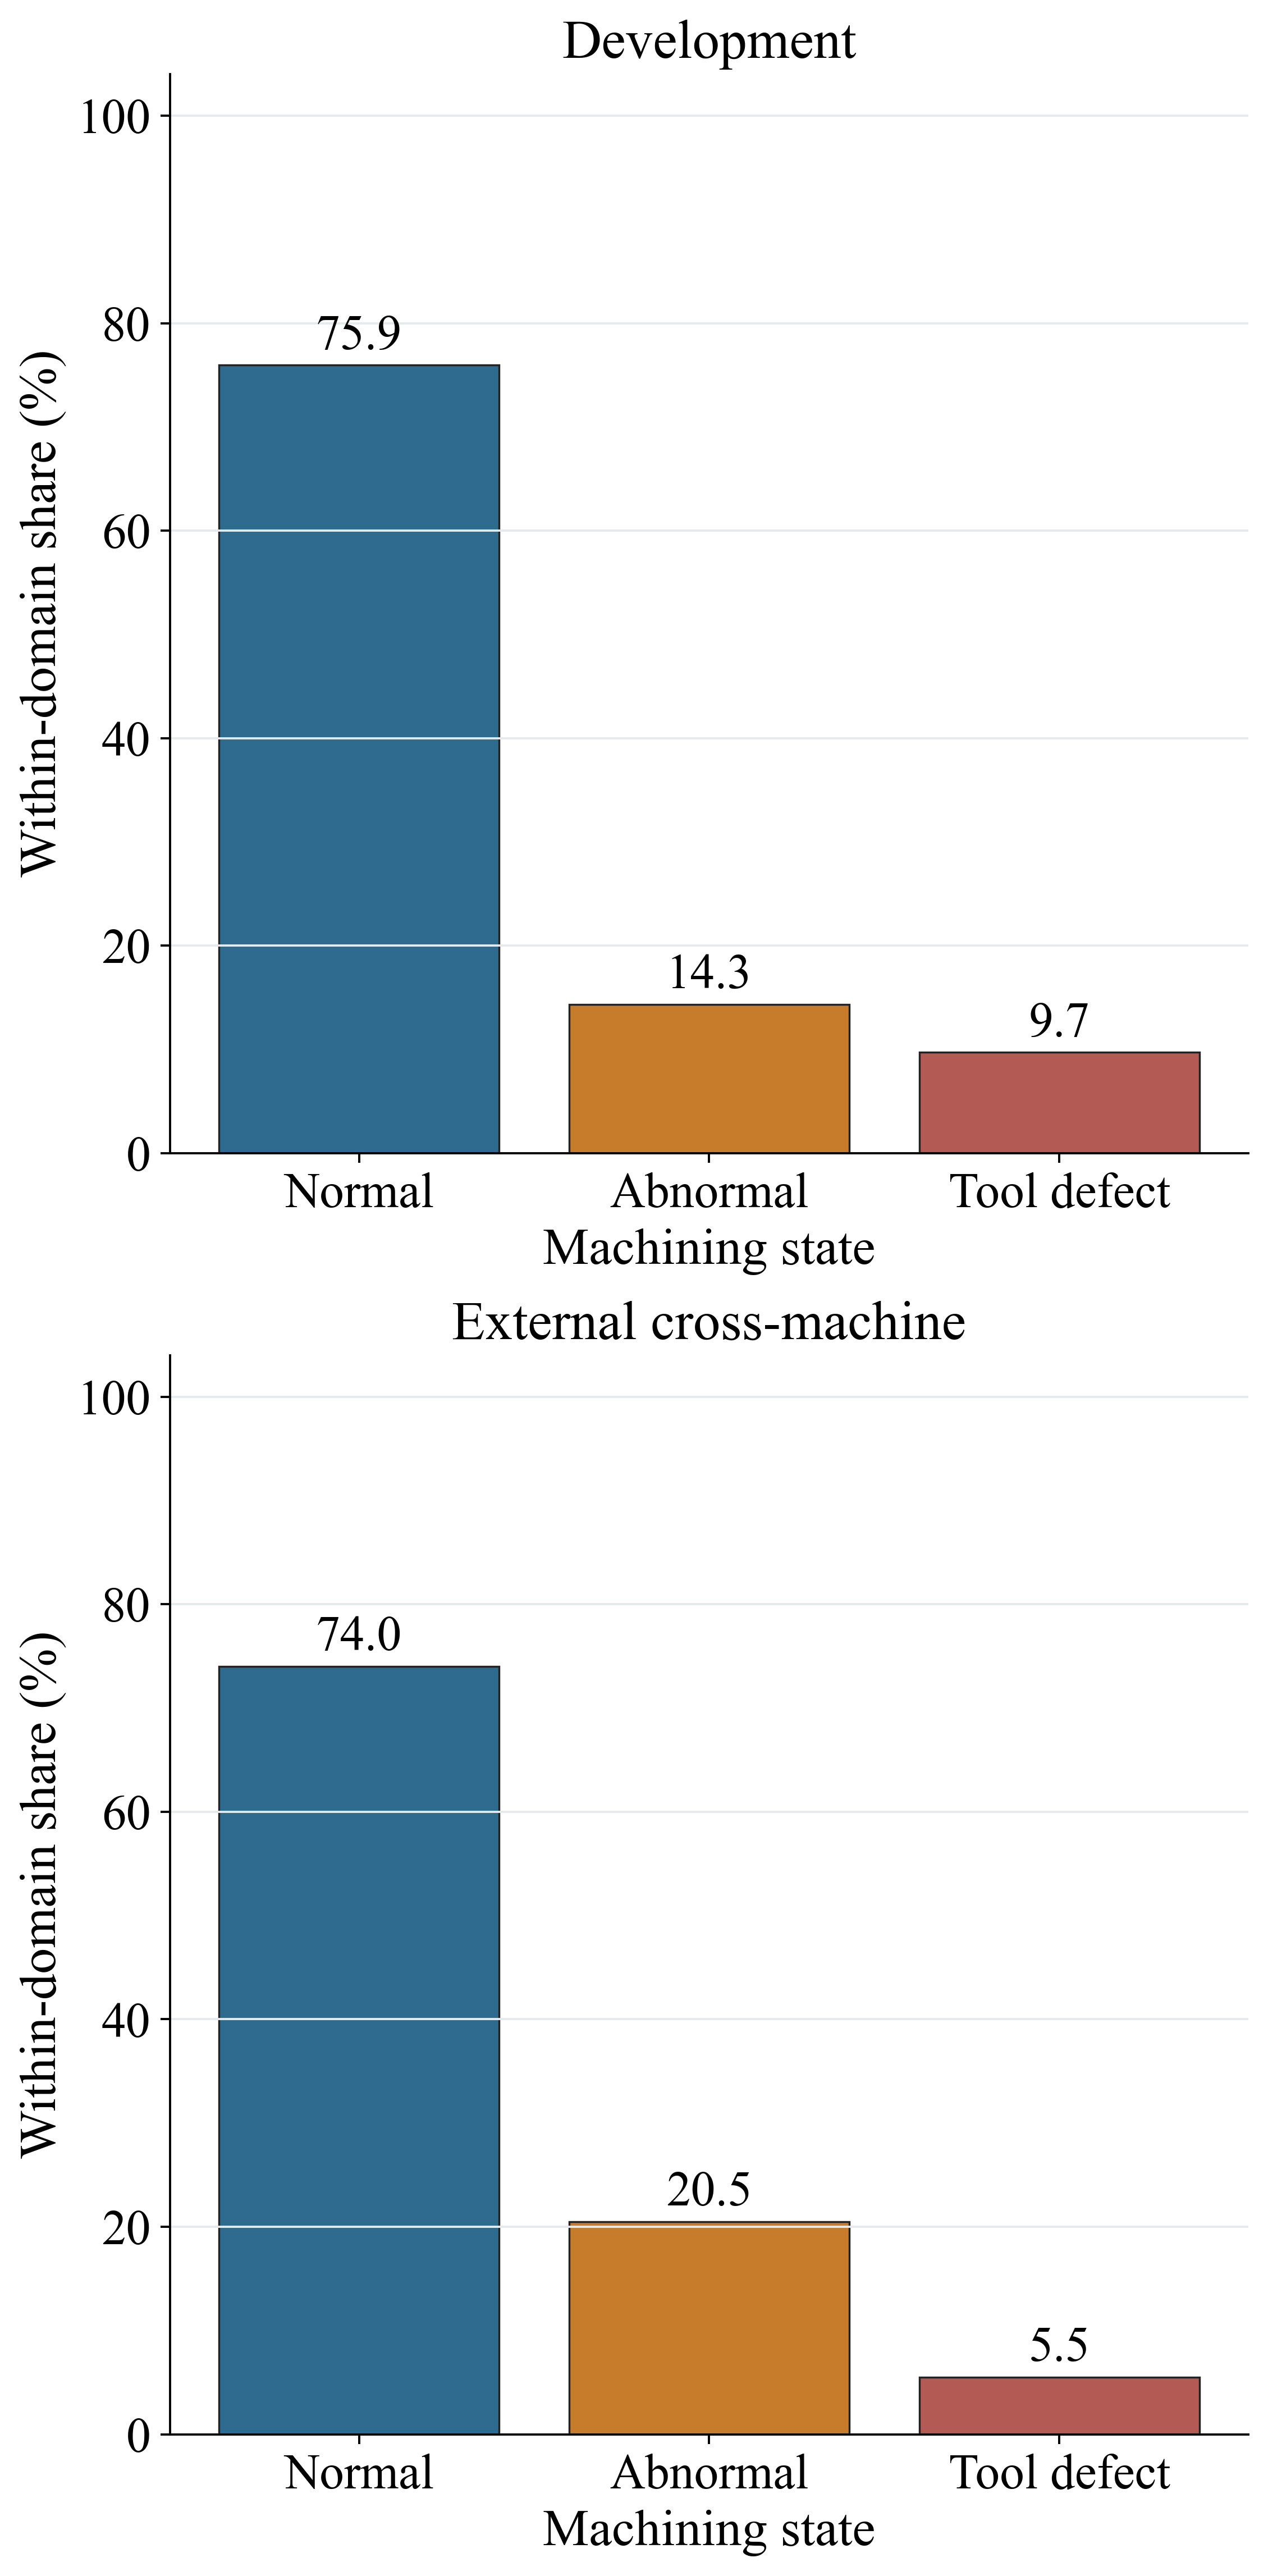

In [16]:
state_names = {0: "Normal", 1: "Abnormal", 2: "Tool defect"}
domain_names = {
    "imi_vmx30ui": "Development",
    "imi_vm20i": "External cross-machine",
}
target_distribution = (
    path_index.groupby(["machine_id", "StateLabel"], as_index=False)
    .agg(n=("cutting_path_id", "size"))
)
target_distribution["share_percent"] = target_distribution.groupby("machine_id")["n"].transform(
    lambda values: 100.0 * values / values.sum()
)
fig, axes = figure_subplots(
    2, 1, span="double", labels=state_names.values(), sharey=True
)
for ax, machine_id in zip(axes, ["imi_vmx30ui", "imi_vm20i"]):
    subset = target_distribution[target_distribution["machine_id"].eq(machine_id)].set_index("StateLabel")
    values = subset.reindex([0, 1, 2], fill_value=0)["share_percent"].to_numpy()
    bars = ax.bar(
        np.arange(3), values,
        color=[PALETTE["baseline"], PALETTE["validation"], PALETTE["error"]],
        edgecolor=PALETTE["black"], linewidth=0.7,
    )
    ax.set_xticks(np.arange(3), ["Normal", "Abnormal", "Tool defect"])
    ax.set_title(domain_names[machine_id])
    ax.set_xlabel("Machining state")
    ax.set_ylabel("Within-domain share (%)")
    ax.set_ylim(0, max(104.0, values.max() + 14.0))
    annotate_bar_values(ax, digits=1, padding_points=2.0)
    ax.grid(axis="y", color=PALETTE["grid"])
_ = save_show_figure(fig, FIGURES / "01_target_structure.png", span="double")


The canvas shows both class imbalance and the shift in abnormal versus tool-defect composition. It motivates stratified reporting while preserving experiment groups; it does not justify class reweighting before training-fold evaluation.

## Cutting-path duration distribution

How does the full cutting-path duration distribution differ between development and cross-machine domains?

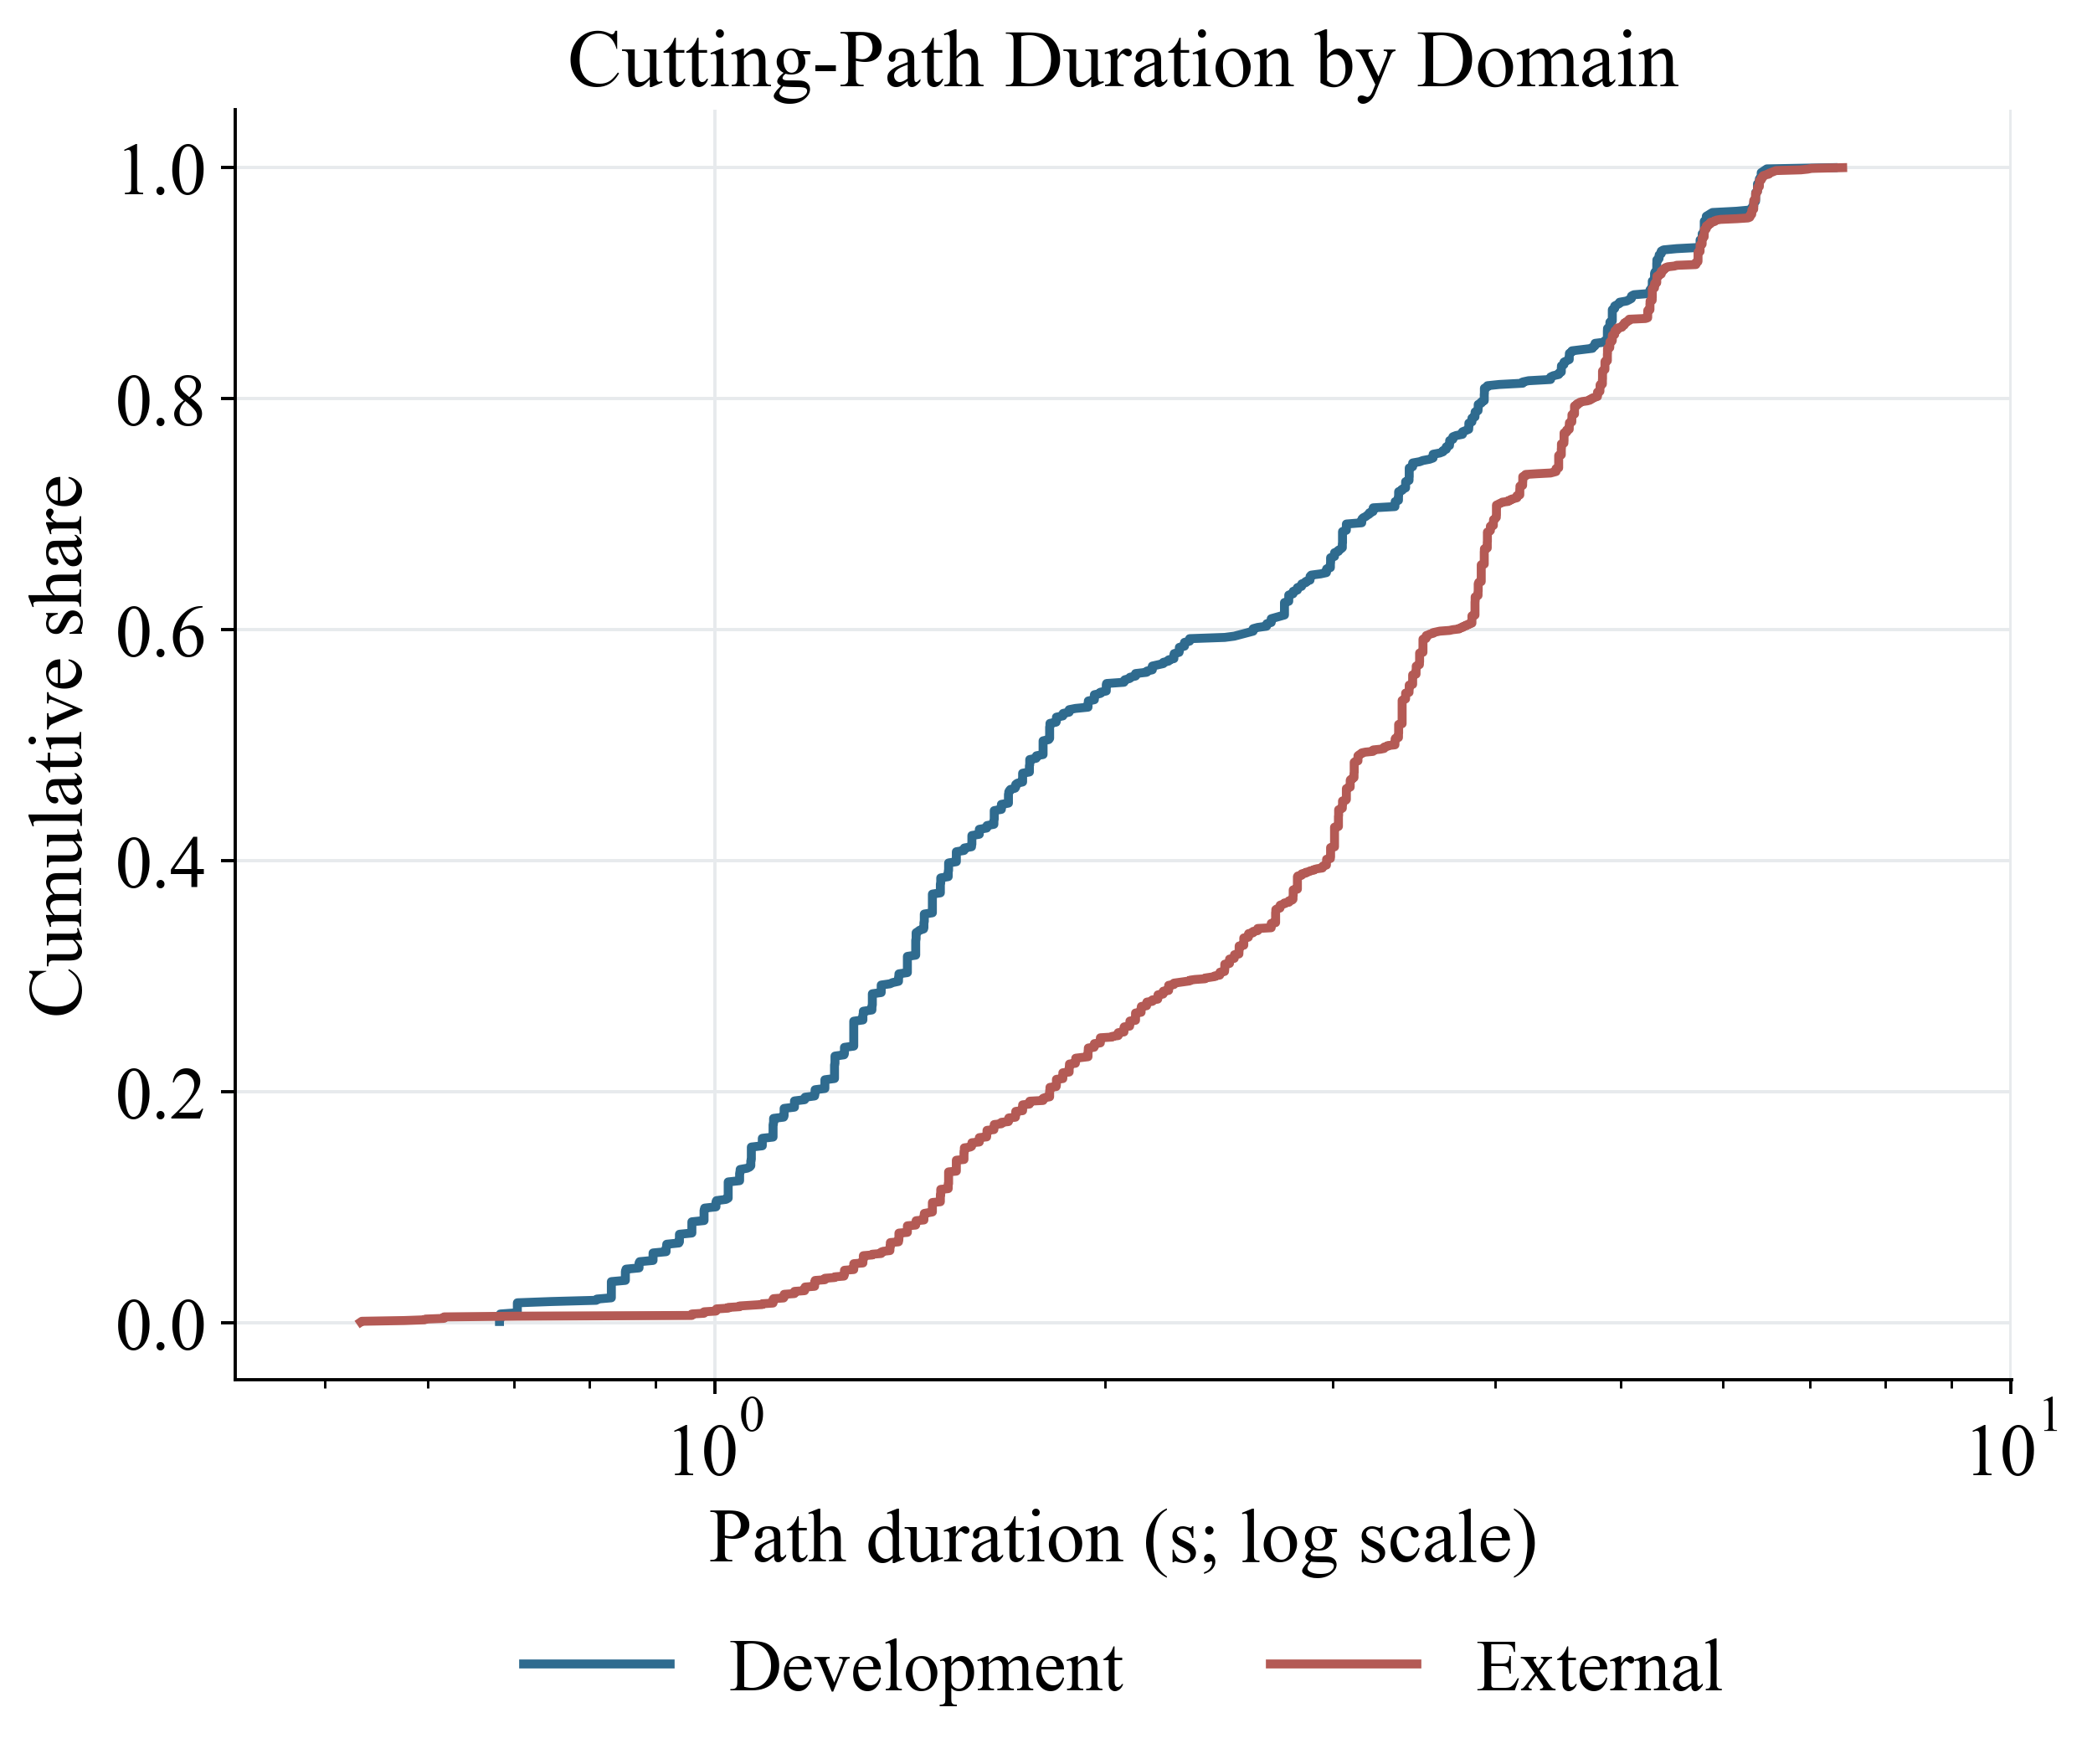

In [17]:
experiment_registry = (
    path_index.groupby(["machine_id", "experiment_id", "experiment_number"], as_index=False)
    .agg(
        paths=("cutting_path_id", "size"),
        intervention_rate=("InterventionRequired", "mean"),
        median_path_duration_s=("path_duration_s", "median"),
    )
    .merge(
        mtc_audit[[
            "machine_id", "experiment_id", "rows", "experiment_duration_s",
            "median_interval_s", "p95_interval_s", "max_interval_s",
        ]],
        on=["machine_id", "experiment_id"], validate="one_to_one",
    )
)
def ecdf(values: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    """Return finite values and their empirical cumulative probabilities."""

    finite = np.sort(pd.to_numeric(values, errors="coerce").dropna().to_numpy(float))
    return finite, np.arange(1, len(finite) + 1) / max(len(finite), 1)
machines = ["imi_vmx30ui", "imi_vm20i"]
labels = ["Development", "External"]
domain_tick_labels = ["Dev.", "External"]
colors = [PALETTE["lab"], PALETTE["external"]]
fig, ax = figure_subplots(1, 1, span="double", legend_items=2)
for machine_id, label, color in zip(machines, labels, colors):
    duration, cumulative = ecdf(
        path_index.loc[path_index["machine_id"].eq(machine_id), "path_duration_s"]
    )
    ax.plot(duration, cumulative, linewidth=2.2, color=color, label=label)
ax.set_xscale("log")
ax.set_xlabel("Path duration (s; log scale)")
ax.set_ylabel("Cumulative share")
ax.set_title("Cutting-Path Duration by Domain")
duration_values = path_index["path_duration_s"].to_numpy(float)
ax.set_xlim(duration_values.min() * 0.80, duration_values.max() * 1.35)
ax.grid(color=PALETTE["grid"])
legend_below(ax, ncol=2)


In [18]:
_ = save_show_figure(
    fig, FIGURES / "01_path_duration_by_domain.png", span="double"
)


The logarithmic ECDF retains every observed path and exposes both central support and heavy tails without unstable density normalization.

## Experiment-level sampling heterogeneity

How variable is the median sampling interval across independent experiments and machine domains?

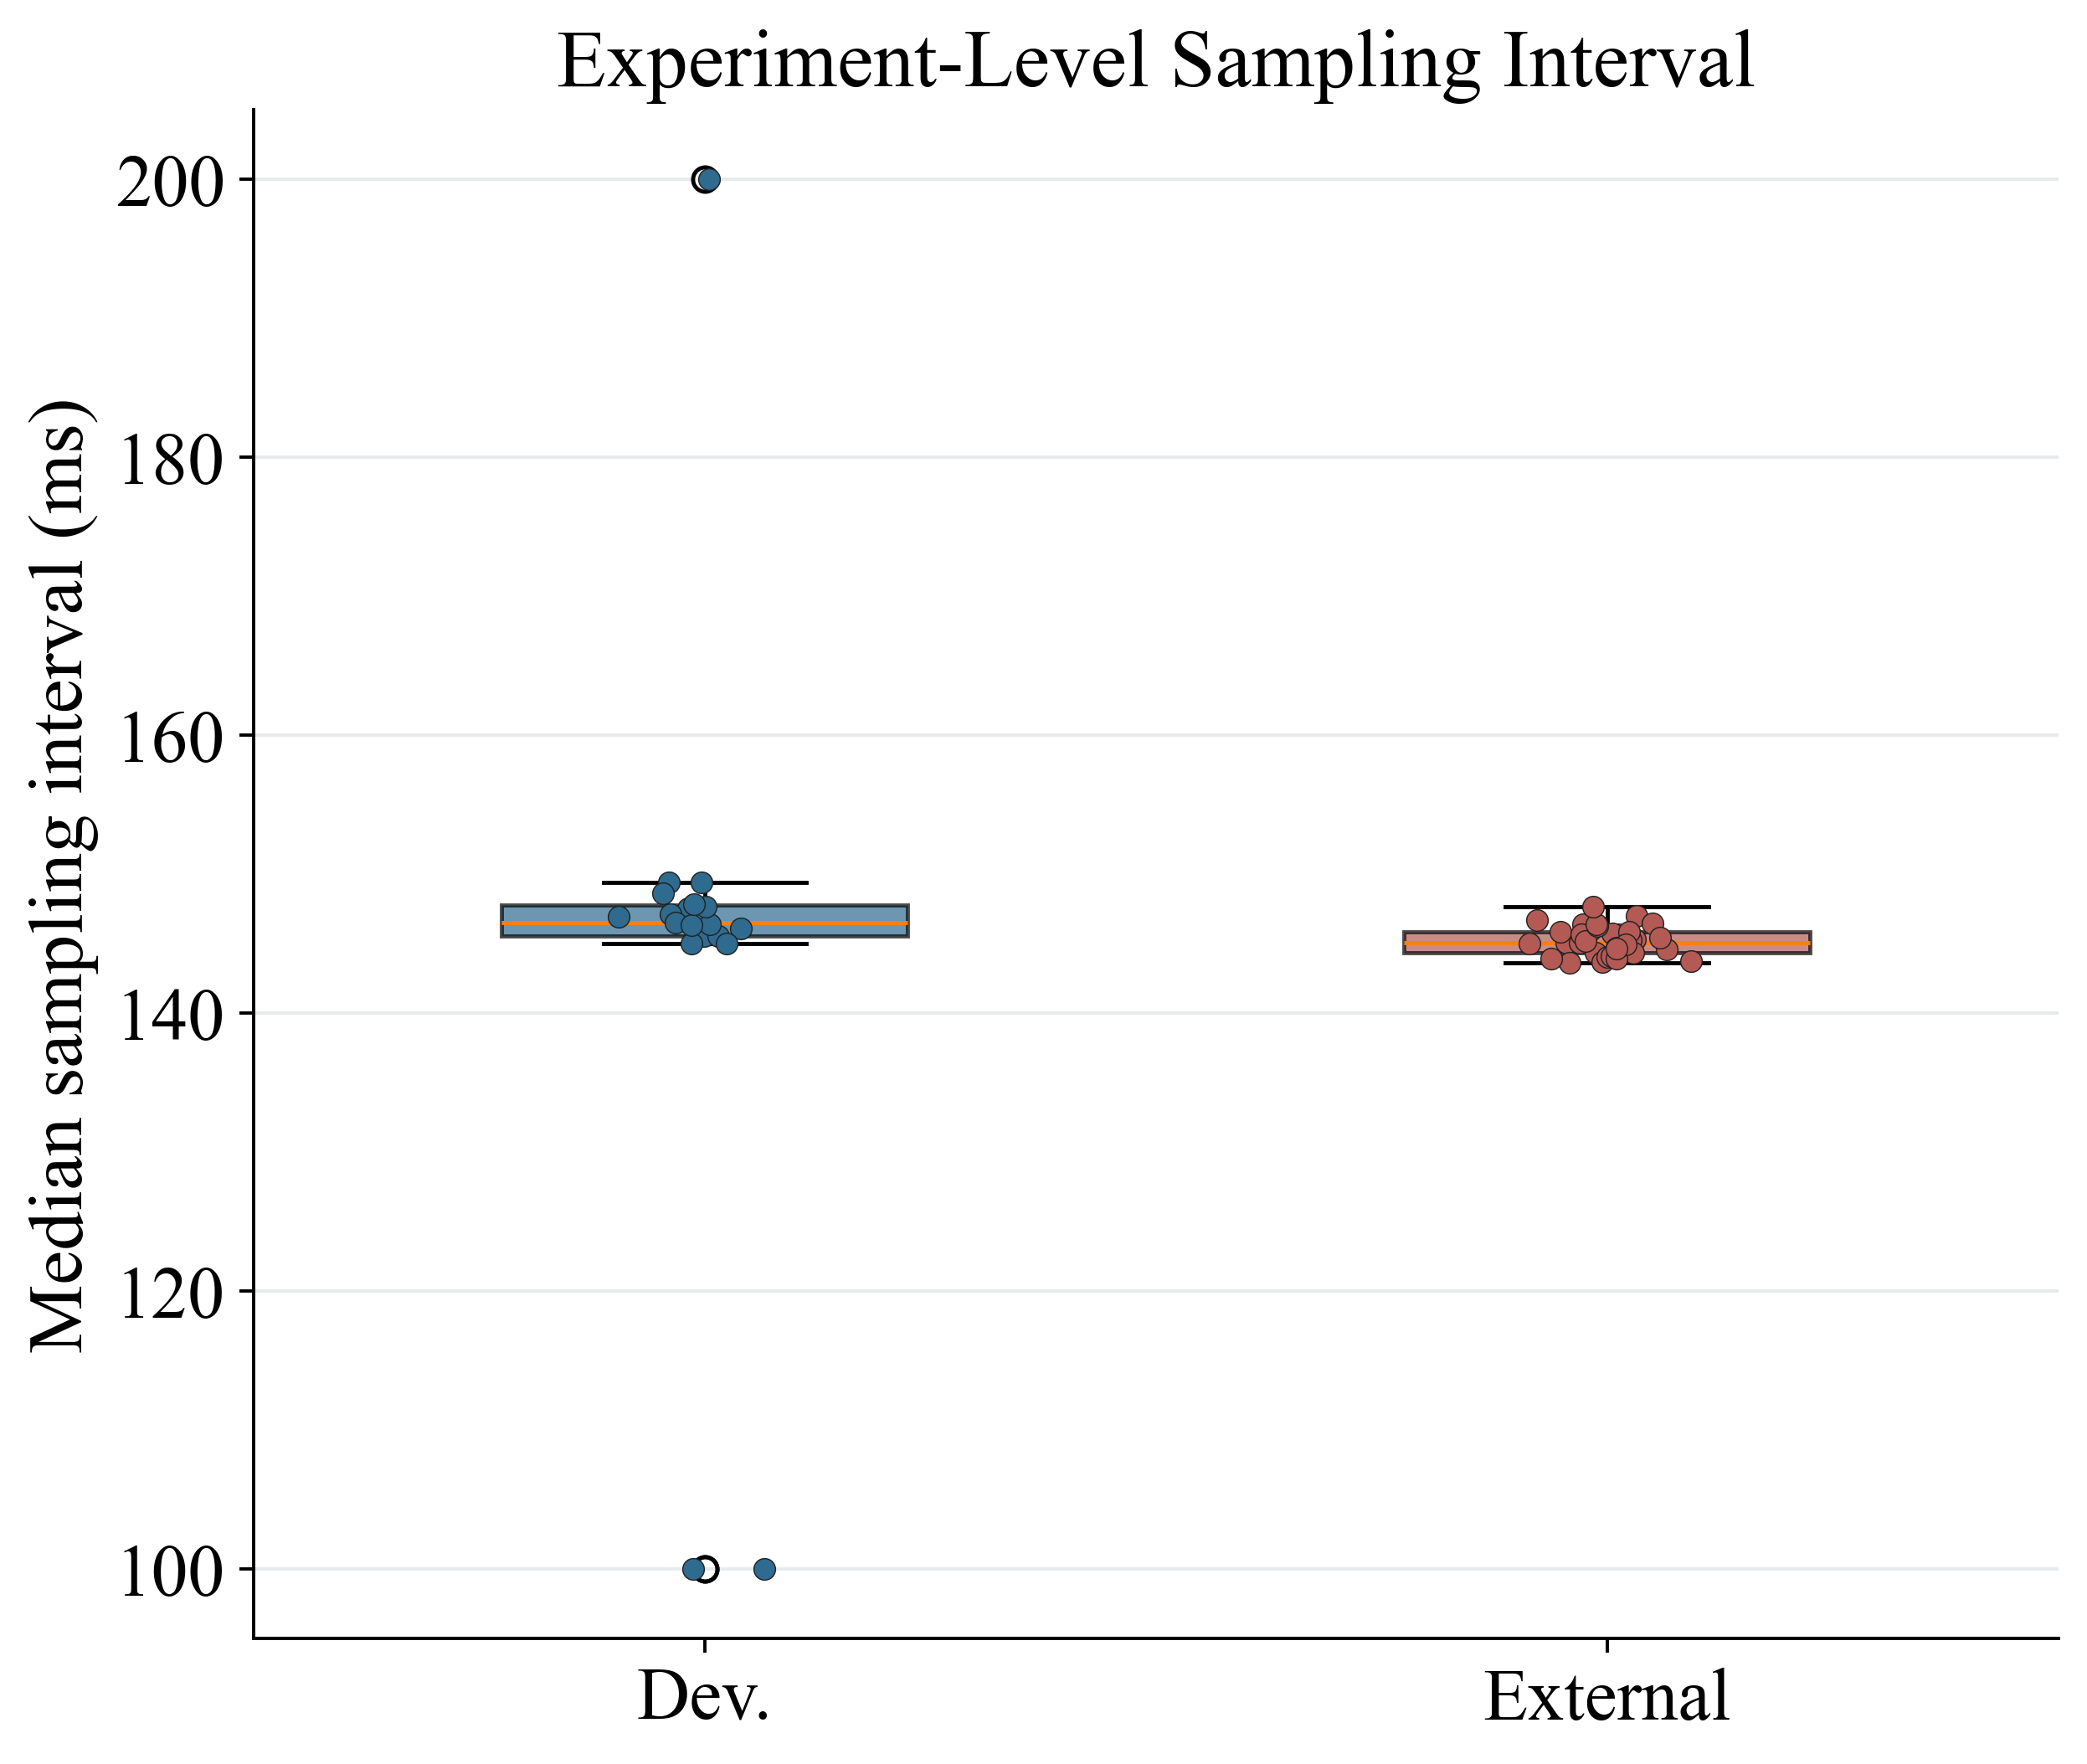

In [19]:
interval_groups = [
    1000.0 * experiment_registry.loc[
        experiment_registry["machine_id"].eq(machine), "median_interval_s"
    ].to_numpy()
    for machine in machines
]
fig, ax = figure_subplots(1, 1, span="double")
boxes = ax.boxplot(
    interval_groups, tick_labels=domain_tick_labels,
    patch_artist=True, widths=0.45,
)
for patch, color in zip(boxes["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.70)
for group_index, (values, color) in enumerate(
    zip(interval_groups, colors), start=1
):
    jitter = np.random.default_rng(SEED + group_index).normal(
        group_index, 0.035, len(values)
    )
    ax.scatter(
        jitter, values, s=28, color=color,
        edgecolor=PALETTE["black"], linewidth=0.3, zorder=3,
    )
ax.set_ylabel("Median sampling interval (ms)")
ax.set_title("Experiment-Level Sampling Interval")
ax.grid(axis="y", color=PALETTE["grid"])
_ = save_show_figure(
    fig, FIGURES / "01_sampling_interval_by_experiment.png", span="double"
)


Sampling intervals are summarized per independent experiment, so dense experiments cannot dominate the comparison through a larger number of timestamps.

## Experiment-level target heterogeneity

How variable is intervention prevalence across independent experiments and domains?

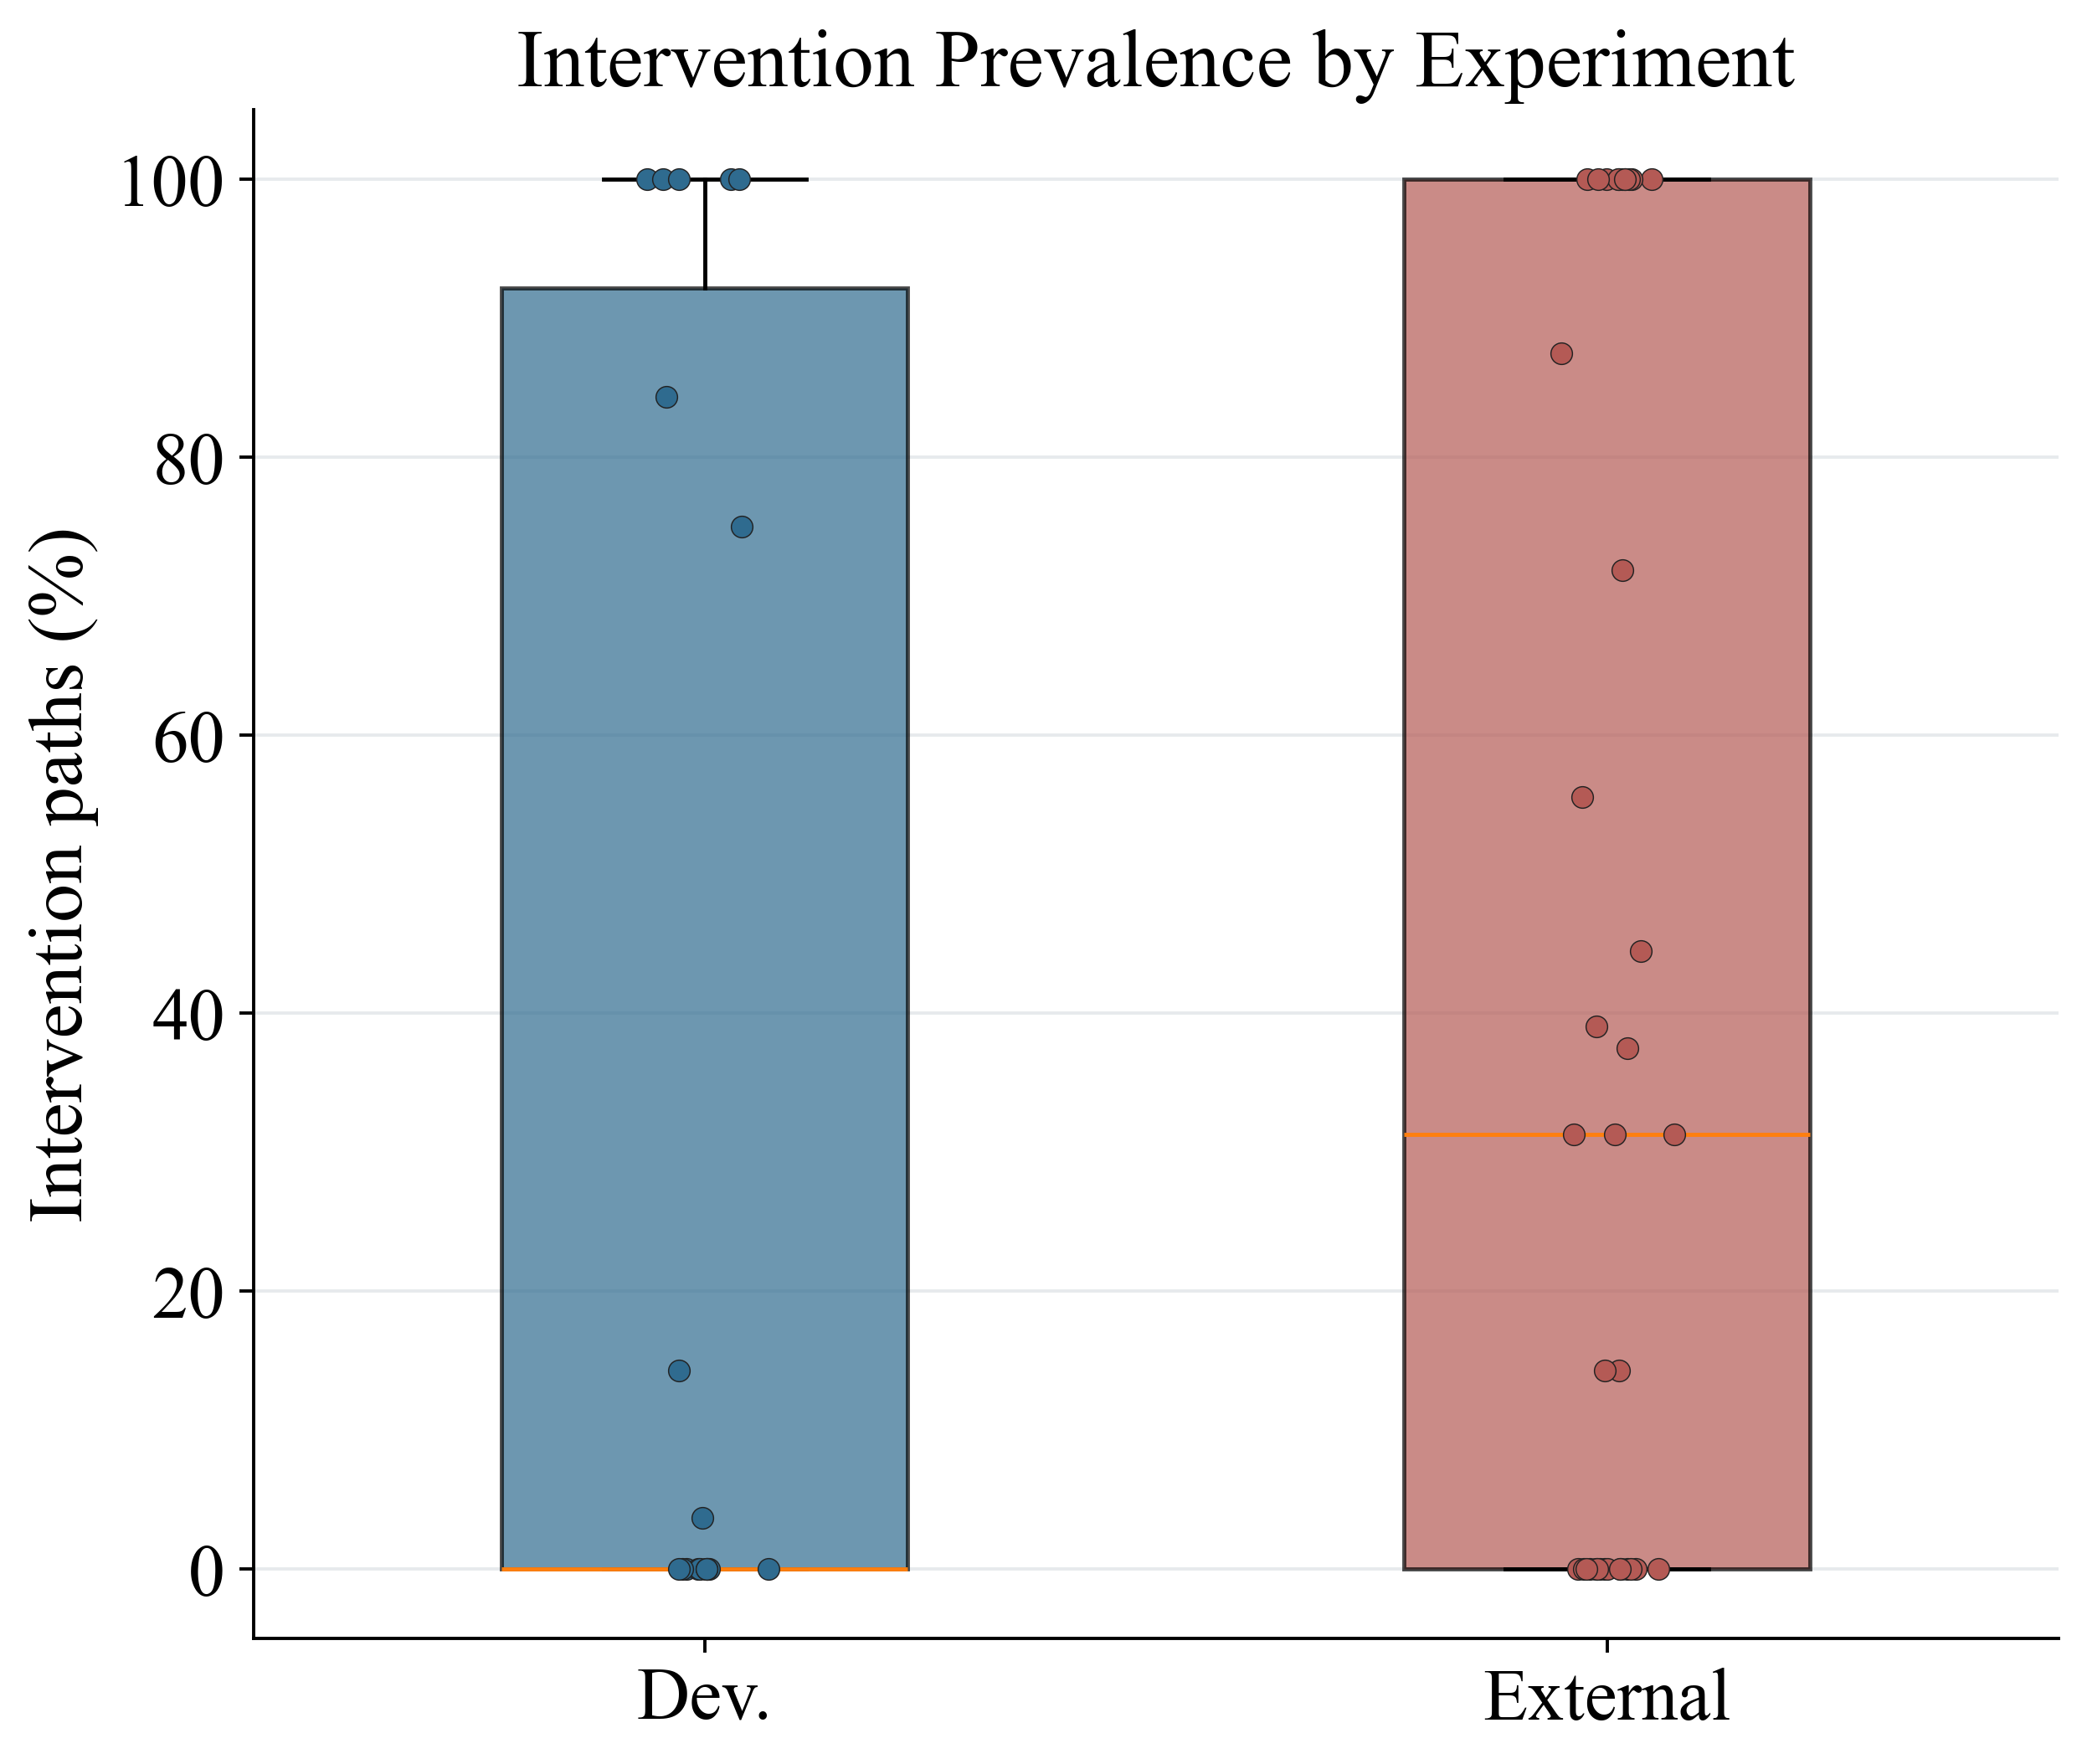

In [20]:
prevalence_groups = [
    100.0 * experiment_registry.loc[
        experiment_registry["machine_id"].eq(machine), "intervention_rate"
    ].to_numpy()
    for machine in machines
]
fig, ax = figure_subplots(1, 1, span="double")
boxes = ax.boxplot(
    prevalence_groups, tick_labels=domain_tick_labels,
    patch_artist=True, widths=0.45,
)
for patch, color in zip(boxes["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.70)
for group_index, (values, color) in enumerate(
    zip(prevalence_groups, colors), start=1
):
    jitter = np.random.default_rng(SEED + 20 + group_index).normal(
        group_index, 0.035, len(values)
    )
    ax.scatter(
        jitter, values, s=28, color=color,
        edgecolor=PALETTE["black"], linewidth=0.3, zorder=3,
    )
ax.set_ylabel("Intervention paths (%)")
ax.set_title("Intervention Prevalence by Experiment")
ax.grid(axis="y", color=PALETTE["grid"])
_ = save_show_figure(
    fig, FIGURES / "01_experiment_prevalence.png", span="double"
)


Aggregate class balance hides strong between-experiment prevalence variation; group-preserving evaluation is therefore mandatory.

## Experiment duration and labeled-path support

Does a longer experiment necessarily provide more labeled cutting paths, and is this relationship domain-dependent?

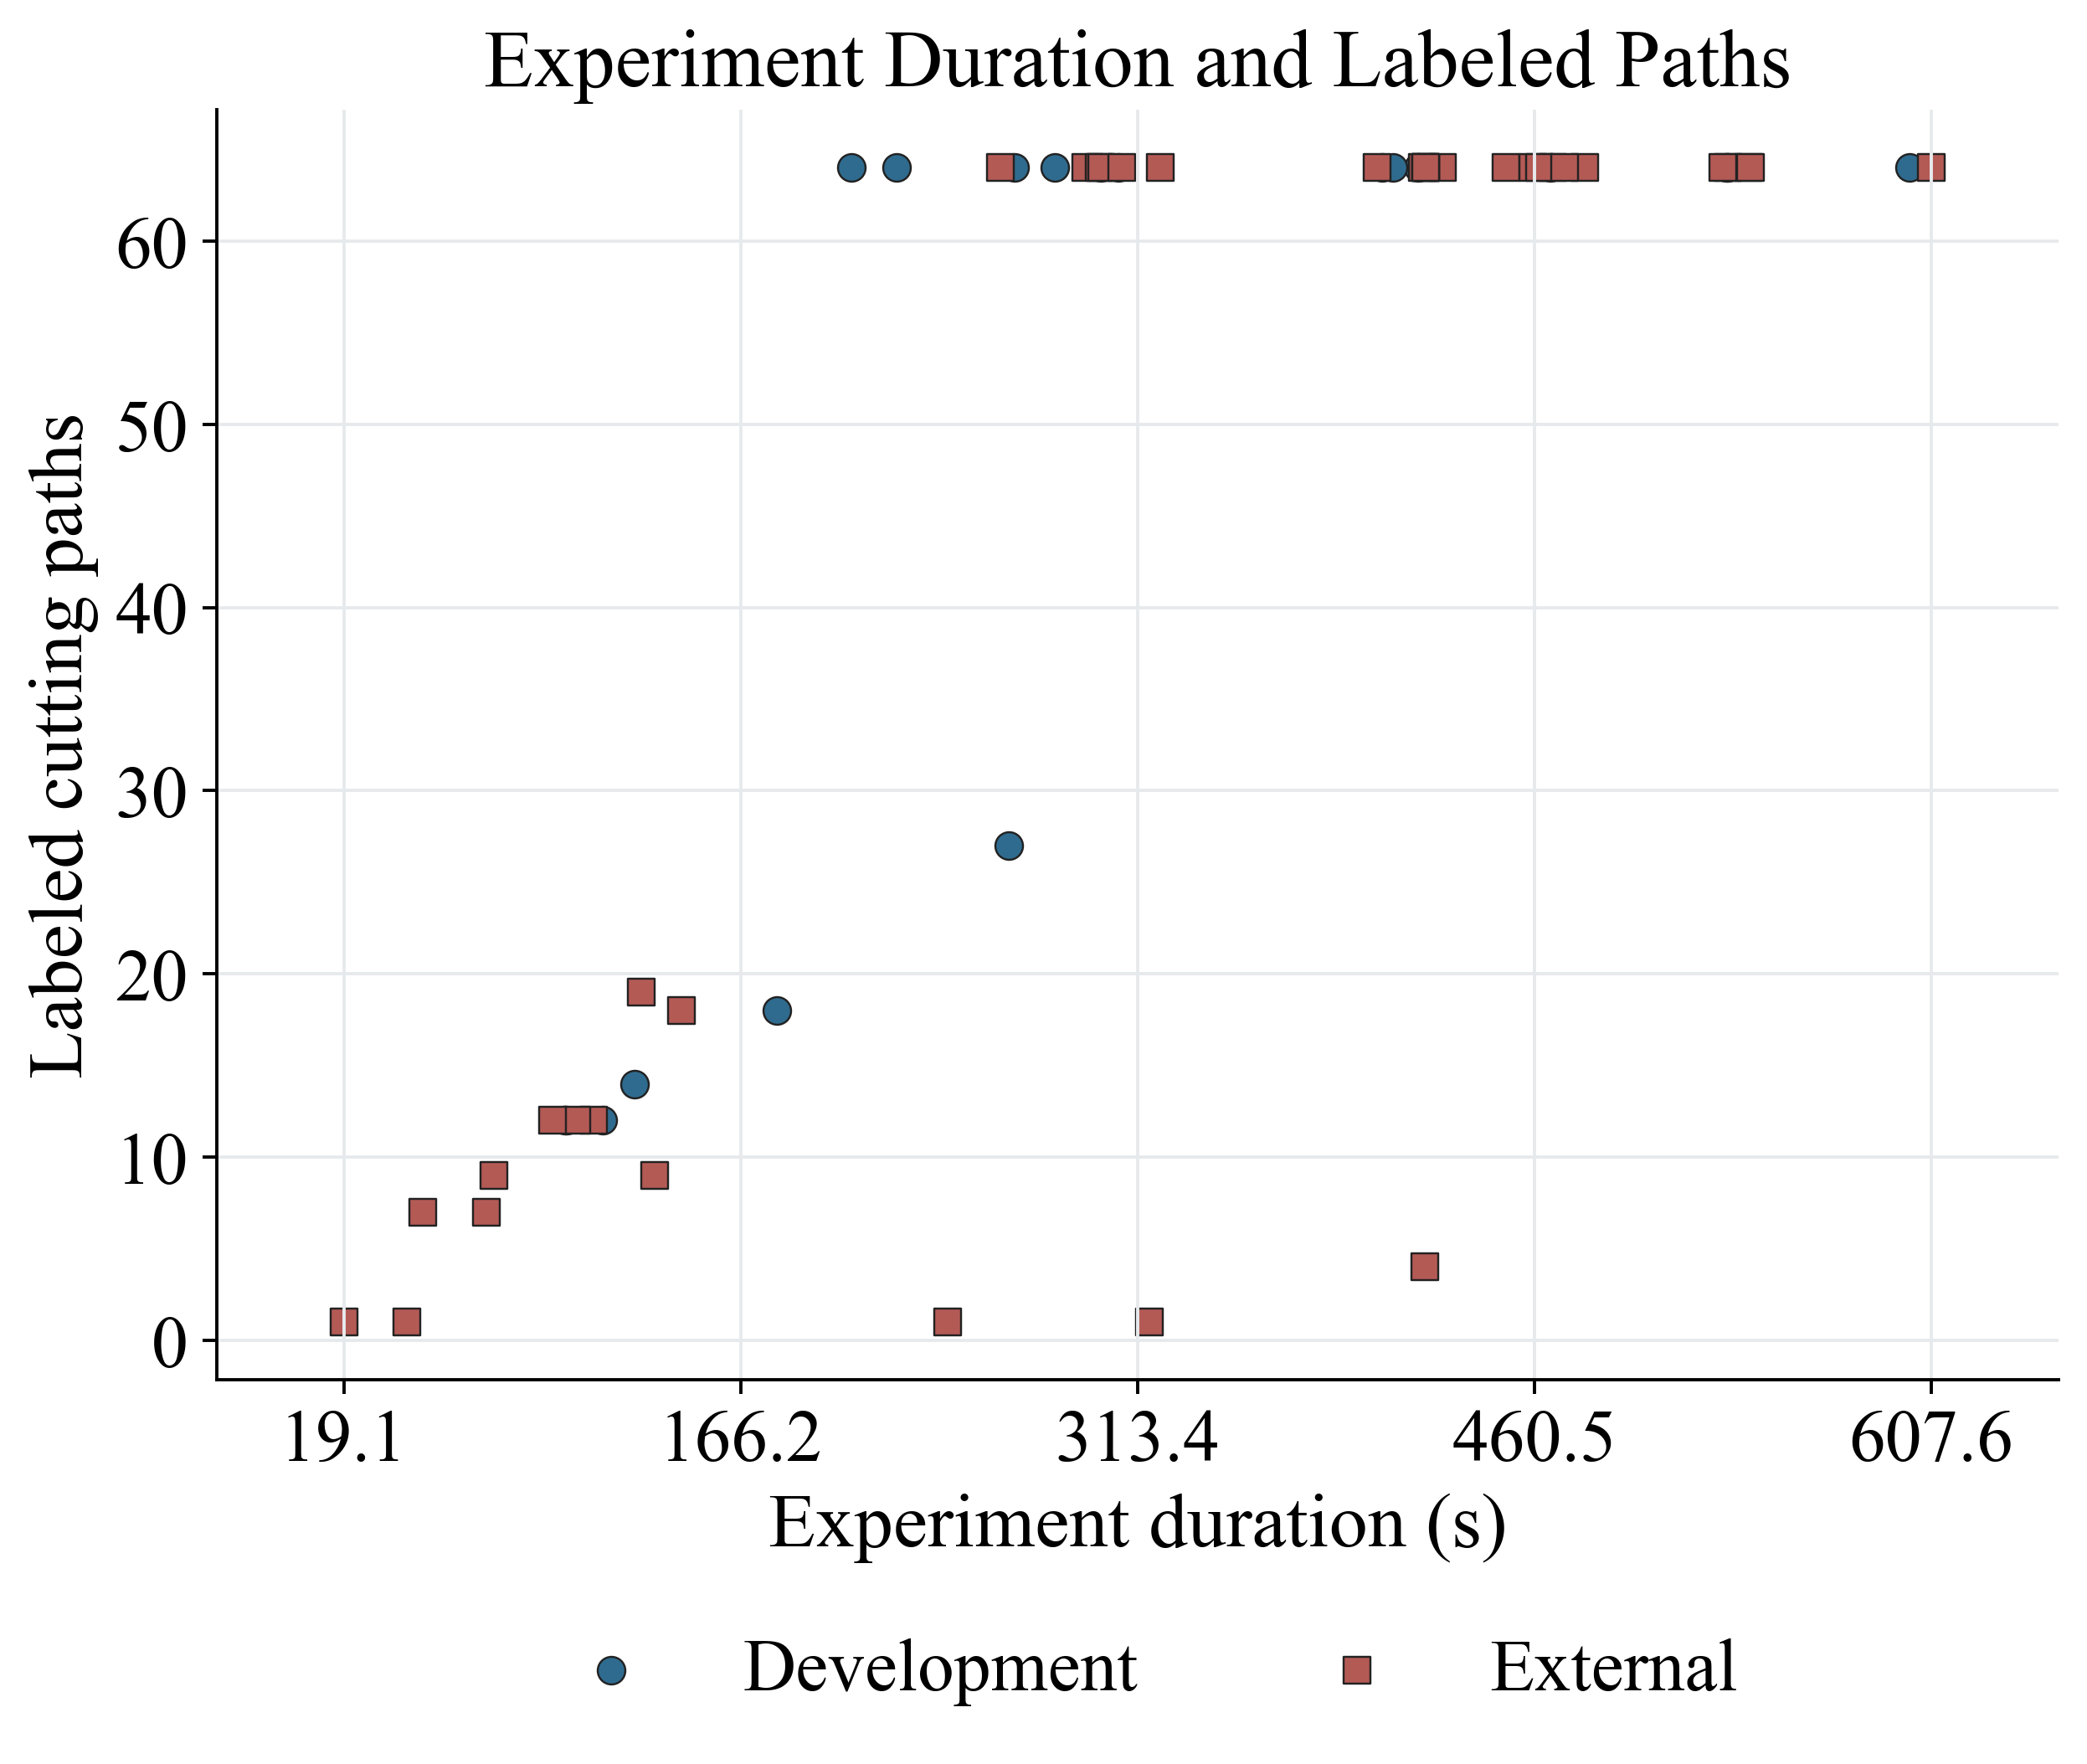

In [21]:
fig, ax = figure_subplots(1, 1, span="double", legend_items=2)
for machine_id, label, color, marker in zip(
    machines, labels, colors, ["o", "s"]
):
    part = experiment_registry[
        experiment_registry["machine_id"].eq(machine_id)
    ]
    ax.scatter(
        part["experiment_duration_s"], part["paths"],
        s=46, marker=marker, color=color,
        edgecolor=PALETTE["black"], linewidth=0.5, label=label,
    )
duration_minimum = experiment_registry["experiment_duration_s"].min()
duration_maximum = experiment_registry["experiment_duration_s"].max()
duration_span = max(duration_maximum - duration_minimum, 1.0)
ax.set_xlim(
    duration_minimum - 0.08 * duration_span,
    duration_maximum + 0.08 * duration_span,
)
ax.set_xticks(np.linspace(duration_minimum, duration_maximum, 5))
ax.set_xlabel("Experiment duration (s)")
ax.set_ylabel("Labeled cutting paths")
ax.set_title("Experiment Duration and Labeled Paths")
ax.grid(color=PALETTE["grid"])
legend_below(ax, ncol=2)
_ = save_show_figure(
    fig, FIGURES / "01_experiment_size_duration.png", span="double"
)


Experiment duration and labeled-path count are related but not interchangeable; the experiment remains the independent resampling unit.

## Scientific quality of observations

What exact burden is created by duplicate identifiers, impossible intervals, coverage failures, timestamp duplication, overlap, and raw-cell missingness?

In [22]:
source_key_duplicates = int(
    path_index.duplicated(
        ["machine_id", "experiment_id", "start", "end", "original_label"]
    ).sum()
)
nested_intervals = 0
for _, group in path_index.groupby(["machine_id", "experiment_id"], sort=False):
    ordered = group.sort_values(["start", "end"])
    previous_max_end = ordered["end"].cummax().shift()
    nested_intervals += int((ordered["end"] <= previous_max_end).fillna(False).sum())
quality_rows = [
    ("All", "Cutting path", "Duplicate generated identifier", int(path_index["cutting_path_id"].duplicated().sum()), len(path_index)),
    ("All", "Cutting path", "Duplicate original interval key", source_key_duplicates, len(path_index)),
    ("All", "Cutting path", "Non-positive duration", int((path_index["path_duration_s"] <= 0).sum()), len(path_index)),
    ("All", "Cutting path", "Outside MTC coverage", int((~path_index["within_mtc_coverage"]).sum()), len(path_index)),
    ("All", "Cutting path", "Overlap with previous interval", int(path_index["overlap_with_previous"].sum()), len(path_index)),
    ("All", "Cutting path", "Nested labeled interval", nested_intervals, len(path_index)),
    ("All", "MTC timestamp", "Duplicate timestamp", int(mtc_audit["duplicate_timestamps"].sum()), int(mtc_audit["rows"].sum())),
]
quality_summary = pd.DataFrame(
    quality_rows,
    columns=["domain", "scientific_unit", "quality_dimension", "affected_n", "denominator_n"],
)
raw_missing = (
    feature_inventory.groupby("machine_id", as_index=False)
    .agg(affected_n=("missing_count", "sum"), denominator_n=("row_count", "sum"))
)
raw_missing["domain"] = raw_missing["machine_id"].map(domain_names)
raw_missing["scientific_unit"] = "Raw feature observation"
raw_missing["quality_dimension"] = "Raw-cell missing value"
quality_summary = pd.concat(
    [
        quality_summary,
        raw_missing[[
            "domain", "scientific_unit", "quality_dimension", "affected_n", "denominator_n",
        ]],
    ],
    ignore_index=True,
)


In [23]:
quality_summary["affected_percent"] = (
    100.0 * quality_summary["affected_n"] / quality_summary["denominator_n"].clip(lower=1)
)
display_grouped_tables(
    quality_summary,
    identifier_columns=["domain", "scientific_unit", "quality_dimension"],
    column_groups={
        "Observed quality burden": ["affected_n", "denominator_n", "affected_percent"]
    },
    digits=4,
)


#### Observed quality burden

,domain,scientific_unit,quality_dimension,affected_n,denominator_n,affected_percent
0,All,Cutting path,Duplicate generated identifier,0,2512,0.0000
1,All,Cutting path,Duplicate original interval key,0,2512,0.0000
2,All,Cutting path,Non-positive duration,0,2512,0.0000
3,All,Cutting path,Outside MTC coverage,0,2512,0.0000
4,All,Cutting path,Overlap with previous interval,0,2512,0.0000
5,All,Cutting path,Nested labeled interval,0,2512,0.0000
6,All,MTC timestamp,Duplicate timestamp,0,116346,0.0000
7,External cross-machine,Raw feature observation,Raw-cell missing value,0,4006917,0.0000
8,Development,Raw feature observation,Raw-cell missing value,0,2077845,0.0000


Raw-cell completeness is distinct from structural channel absence and from engineered-prefix missingness. Those later mechanisms are analyzed separately in Notebook 02. A generated identifier being unique is not accepted as sufficient evidence; the original interval key is also tested.

## Raw-cell completeness by feature family

Which raw feature families contain missing cells when the channel is structurally present in an experiment?

In [24]:
missing_by_group = (
    feature_inventory.groupby(["machine_id", "feature_group"], as_index=False)
    .agg(
        available_features=("feature", "nunique"),
        missing_cells=("missing_count", "sum"),
        observed_feature_cells=("row_count", "sum"),
    )
)
missing_by_group["missing_rate"] = (
    missing_by_group["missing_cells"]
    / missing_by_group["observed_feature_cells"].clip(lower=1)
)
missing_by_group["domain_role"] = missing_by_group["machine_id"].map(domain_names)
display_grouped_tables(
    missing_by_group,
    identifier_columns=["machine_id", "domain_role", "feature_group"],
    column_groups={
        "Structurally present support": [
            "available_features", "observed_feature_cells",
        ],
        "Raw-cell incompleteness": ["missing_cells", "missing_rate"],
    },
    digits=4,
)


#### Structurally present support

,machine_id,domain_role,feature_group,available_features,observed_feature_cells
0,imi_vm20i,External cross-machine,condition sensor,16,1257072
1,imi_vm20i,External cross-machine,energy,2,157134
2,imi_vm20i,External cross-machine,load,4,314268
3,imi_vm20i,External cross-machine,machine state,10,785670
4,imi_vm20i,External cross-machine,position,3,235701
5,imi_vm20i,External cross-machine,process/other,7,549969
6,imi_vm20i,External cross-machine,speed/feed,6,471402
7,imi_vm20i,External cross-machine,temporal,3,235701
8,imi_vmx30ui,Development,condition sensor,20,755580
9,imi_vmx30ui,Development,energy,2,75558


#### Raw-cell incompleteness

,machine_id,domain_role,feature_group,missing_cells,missing_rate
0,imi_vm20i,External cross-machine,condition sensor,0,0.0000
1,imi_vm20i,External cross-machine,energy,0,0.0000
2,imi_vm20i,External cross-machine,load,0,0.0000
3,imi_vm20i,External cross-machine,machine state,0,0.0000
4,imi_vm20i,External cross-machine,position,0,0.0000
5,imi_vm20i,External cross-machine,process/other,0,0.0000
6,imi_vm20i,External cross-machine,speed/feed,0,0.0000
7,imi_vm20i,External cross-machine,temporal,0,0.0000
8,imi_vmx30ui,Development,condition sensor,0,0.0000
9,imi_vmx30ui,Development,energy,0,0.0000


Raw-cell missingness is conditioned on a channel being present. Structural absence across acquisition domains is a different mechanism and is summarized separately.

## Structural feature availability

Which raw-channel families are shared across machines, and which are structurally domain-specific?

In [25]:
feature_presence = (
    feature_inventory.assign(present=1)
    .pivot_table(
        index=["feature", "feature_group"],
        columns="machine_id",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
    .reset_index()
)
def summarize_structural_support(group_name, frame):
    """Summarize domain-specific and shared acquisition features."""
    development = frame["imi_vmx30ui"].astype(bool)
    external = frame["imi_vm20i"].astype(bool)
    union_count = int((development | external).sum())
    shared_count = int((development & external).sum())
    return {
        "feature_group": group_name,
        "development_feature_count": int(development.sum()),
        "external_feature_count": int(external.sum()),
        "union_feature_count": union_count,
        "shared_feature_count": shared_count,
        "development_only_count": int((development & ~external).sum()),
        "external_only_count": int((external & ~development).sum()),
        "shared_percent_of_union": 100.0 * shared_count / union_count,
    }
structural_rows = [
    summarize_structural_support(group_name, group)
    for group_name, group in feature_presence.groupby("feature_group", sort=True)
]
structural_rows.append(summarize_structural_support("All features", feature_presence))
structural_availability = pd.DataFrame(structural_rows)


In [26]:
display_grouped_tables(
    structural_availability,
    identifier_columns=["feature_group"],
    column_groups={
        "Domain feature support": [
            "development_feature_count",
            "external_feature_count",
            "union_feature_count",
        ],
        "Cross-domain intersection": [
            "shared_feature_count",
            "development_only_count",
            "external_only_count",
            "shared_percent_of_union",
        ],
    },
    digits=2,
)


#### Domain feature support

,feature_group,development_feature_count,external_feature_count,union_feature_count
0,condition sensor,20,16,20
1,energy,2,2,2
2,load,6,4,6
3,machine state,10,10,10
4,position,5,3,5
5,process/other,3,7,7
6,speed/feed,6,6,6
7,temporal,3,3,3
8,All features,55,51,59


#### Cross-domain intersection

,feature_group,shared_feature_count,development_only_count,external_only_count,shared_percent_of_union
0,condition sensor,16,4,0,80.00
1,energy,2,0,0,100.00
2,load,4,2,0,66.67
3,machine state,10,0,0,100.00
4,position,3,2,0,60.00
5,process/other,3,0,4,42.86
6,speed/feed,6,0,0,100.00
7,temporal,3,0,0,100.00
8,All features,47,8,4,79.66


The grouped tables distinguish shared channels from development-only and external-only channels within every physical feature family. Structural absence is treated as a domain property, not as a conventional NA cell.

## XML semantic coverage

Are component, axis, type, and unit descriptors sufficiently documented to support exact cross-machine harmonization?

In [27]:
semantic_coverage_source = semantic_metadata.copy()
semantic_coverage_source["category"] = (
    semantic_coverage_source["category"].astype("string").fillna("Undocumented")
)
semantic_coverage = (
    semantic_coverage_source.groupby(["machine_id", "category"], as_index=False)
    .agg(
        data_items=("feature", "nunique"),
        components=("component", "nunique"),
        axes=("axis", "nunique"),
        units_documented=("units", lambda values: int(values.notna().sum())),
        semantic_types_documented=("semantic_type", lambda values: int(values.notna().sum())),
    )
)
semantic_coverage["unit_documentation_rate"] = (
    semantic_coverage["units_documented"] / semantic_coverage["data_items"].clip(lower=1)
)
semantic_coverage["type_documentation_rate"] = (
    semantic_coverage["semantic_types_documented"] / semantic_coverage["data_items"].clip(lower=1)
)
display_grouped_tables(
    semantic_coverage,
    identifier_columns=["machine_id", "category"],
    column_groups={
        "Semantic structure": ["data_items", "components", "axes"],
        "Descriptor completeness": [
            "units_documented", "unit_documentation_rate",
            "semantic_types_documented", "type_documentation_rate",
        ],
    },
    digits=4,
)


#### Semantic structure

,machine_id,category,data_items,components,axes
0,imi_vm20i,EVENT,13,3,1
1,imi_vm20i,SAMPLE,38,5,5
2,imi_vmx30ui,EVENT,13,3,1
3,imi_vmx30ui,SAMPLE,42,5,7


#### Descriptor completeness

,machine_id,category,units_documented,unit_documentation_rate,semantic_types_documented,type_documentation_rate
0,imi_vm20i,EVENT,0,0.0000,13,1.0000
1,imi_vm20i,SAMPLE,38,1.0000,38,1.0000
2,imi_vmx30ui,EVENT,0,0.0000,13,1.0000
3,imi_vmx30ui,SAMPLE,42,1.0000,42,1.0000


Exact semantic intersection in Notebook 02 will require agreement of type, subtype, units, component, and axis. Raw-name overlap alone is not considered sufficient cross-machine equivalence.

## Representative normal power trace

What does a variance-median normal development path look like in its original temporal support?

In [28]:
def profile_power_experiment(group_item):
    (machine_id, experiment_id), paths = group_item
    mtc_path = PROJECT_ROOT / paths["mtc_file"].iloc[0]
    header = pd.read_csv(mtc_path, encoding="utf-8-sig", nrows=0)
    header.columns = [str(column).strip().lstrip("﻿") for column in header.columns]
    signal_column = "watt"
    if signal_column not in header.columns:
        return []
    raw = pd.read_csv(
        mtc_path, encoding="utf-8-sig", usecols=["time", signal_column], low_memory=False
    )
    raw.columns = [str(column).strip().lstrip("﻿") for column in raw.columns]
    raw["time"] = pd.to_numeric(raw["time"], errors="coerce")
    trajectories = []
    for path in paths.itertuples(index=False):
        segment = raw[raw["time"].between(path.start, path.end)].copy()
        values = pd.to_numeric(segment[signal_column], errors="coerce")
        valid = values.notna() & segment["time"].notna()
        if valid.sum() < 5:
            continue
        time = segment.loc[valid, "time"].to_numpy(float) - float(path.start)
        signal = values.loc[valid].to_numpy(float)
        if len(signal) > 600:
            indices = np.linspace(0, len(signal) - 1, 600).astype(int)
            time, signal = time[indices], signal[indices]
        trajectories.append(
            {
                "cutting_path_id": path.cutting_path_id,
                "machine_id": machine_id,
                "experiment_id": experiment_id,
                "state": int(path.StateLabel),
                "variance": float(np.var(signal, ddof=1)),
                "time": time,
                "signal": signal,
            }
        )
    return trajectories


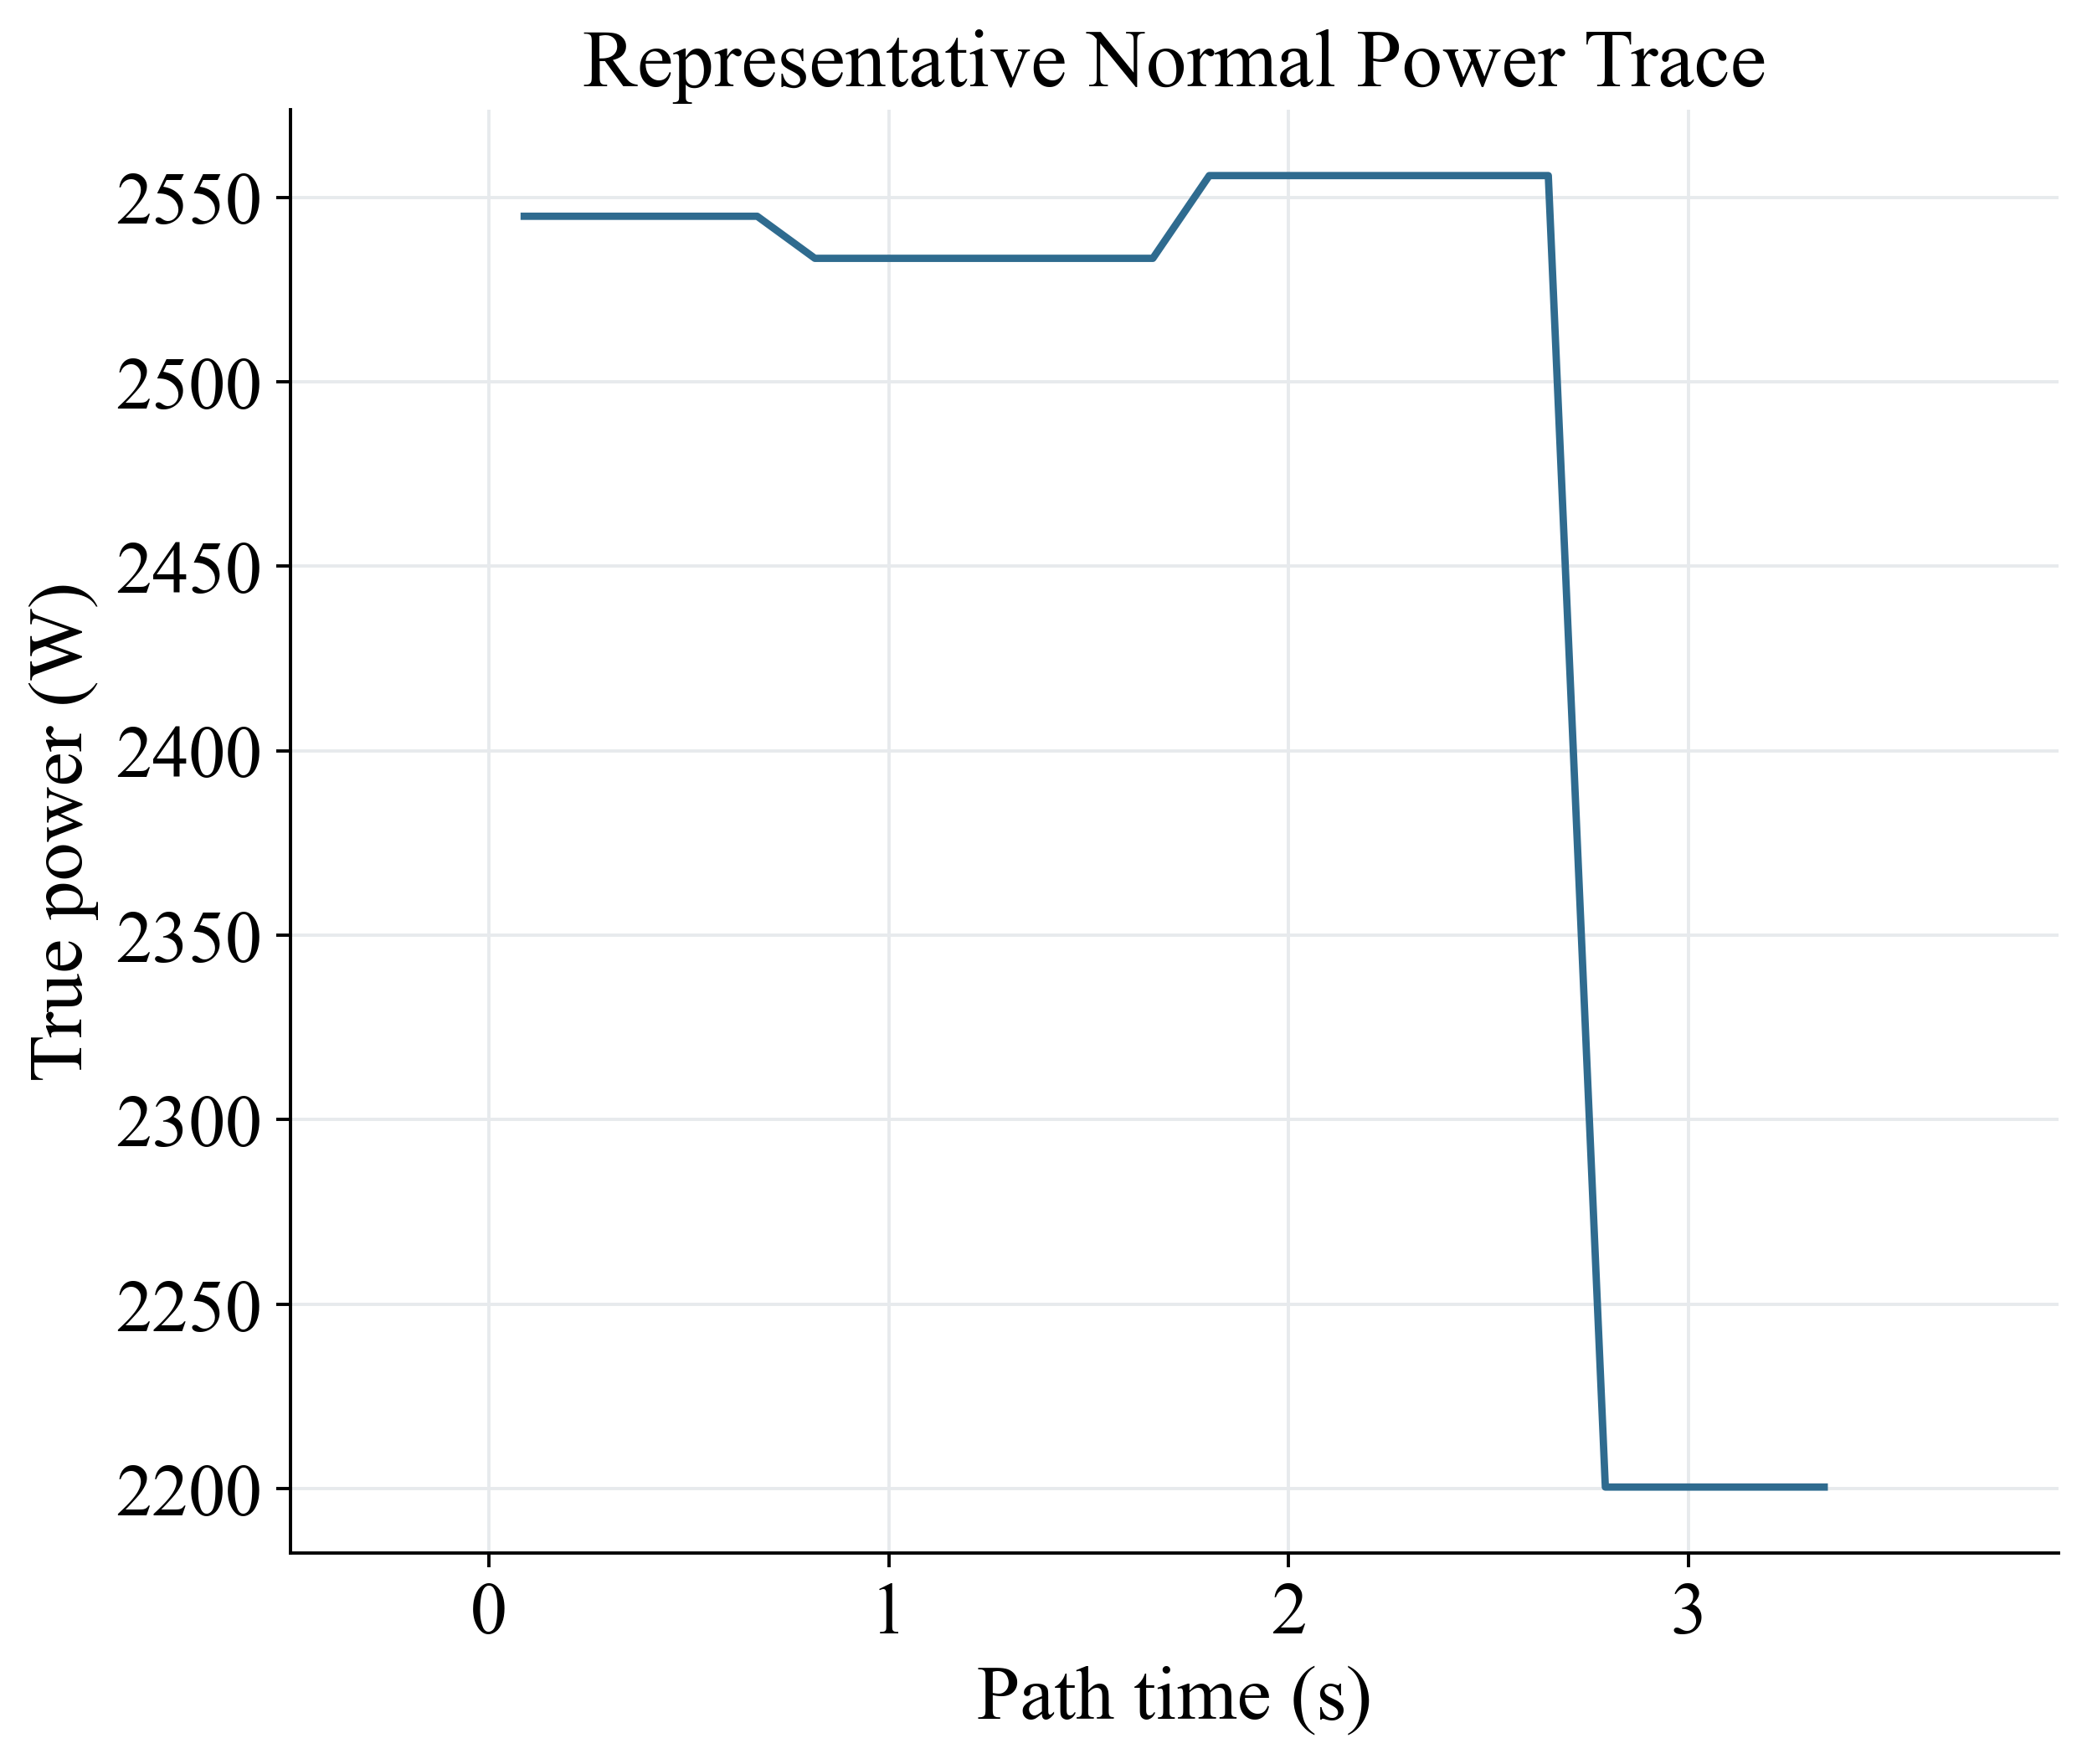

In [29]:
development_groups = list(
    path_index[path_index["machine_id"].eq("imi_vmx30ui")]
    .groupby(["machine_id", "experiment_id"], sort=True)
)
with ThreadPoolExecutor(max_workers=N_JOBS) as pool:
    trajectories = [item for group in pool.map(profile_power_experiment, development_groups) for item in group]
representative = {}
for state in [0, 1, 2]:
    candidates = [item for item in trajectories if item["state"] == state and np.isfinite(item["variance"])]
    assert candidates
    median_variance = float(np.median([item["variance"] for item in candidates]))
    representative[state] = min(candidates, key=lambda item: abs(item["variance"] - median_variance))
trajectory = representative[0]
fig, ax = figure_subplots(1, 1, span="double")
ax.plot(
    trajectory["time"], trajectory["signal"],
    linewidth=1.8, color=PALETTE["baseline"],
)
ax.set_xlabel("Path time (s)")
ax.set_ylabel("True power (W)")
ax.set_title(f"Representative {state_names[0]} Power Trace")
ax.margins(x=0.18)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="lower"))
ax.grid(color=PALETTE["grid"])
_ = save_show_figure(
    fig, FIGURES / "01_representative_normal_signal.png", span="double"
)


The representative is selected deterministically as the path nearest the within-state median signal variance; it is not a hand-picked best case.

## Representative abnormal power trace

How does the variance-median abnormal development path evolve over its observed duration?

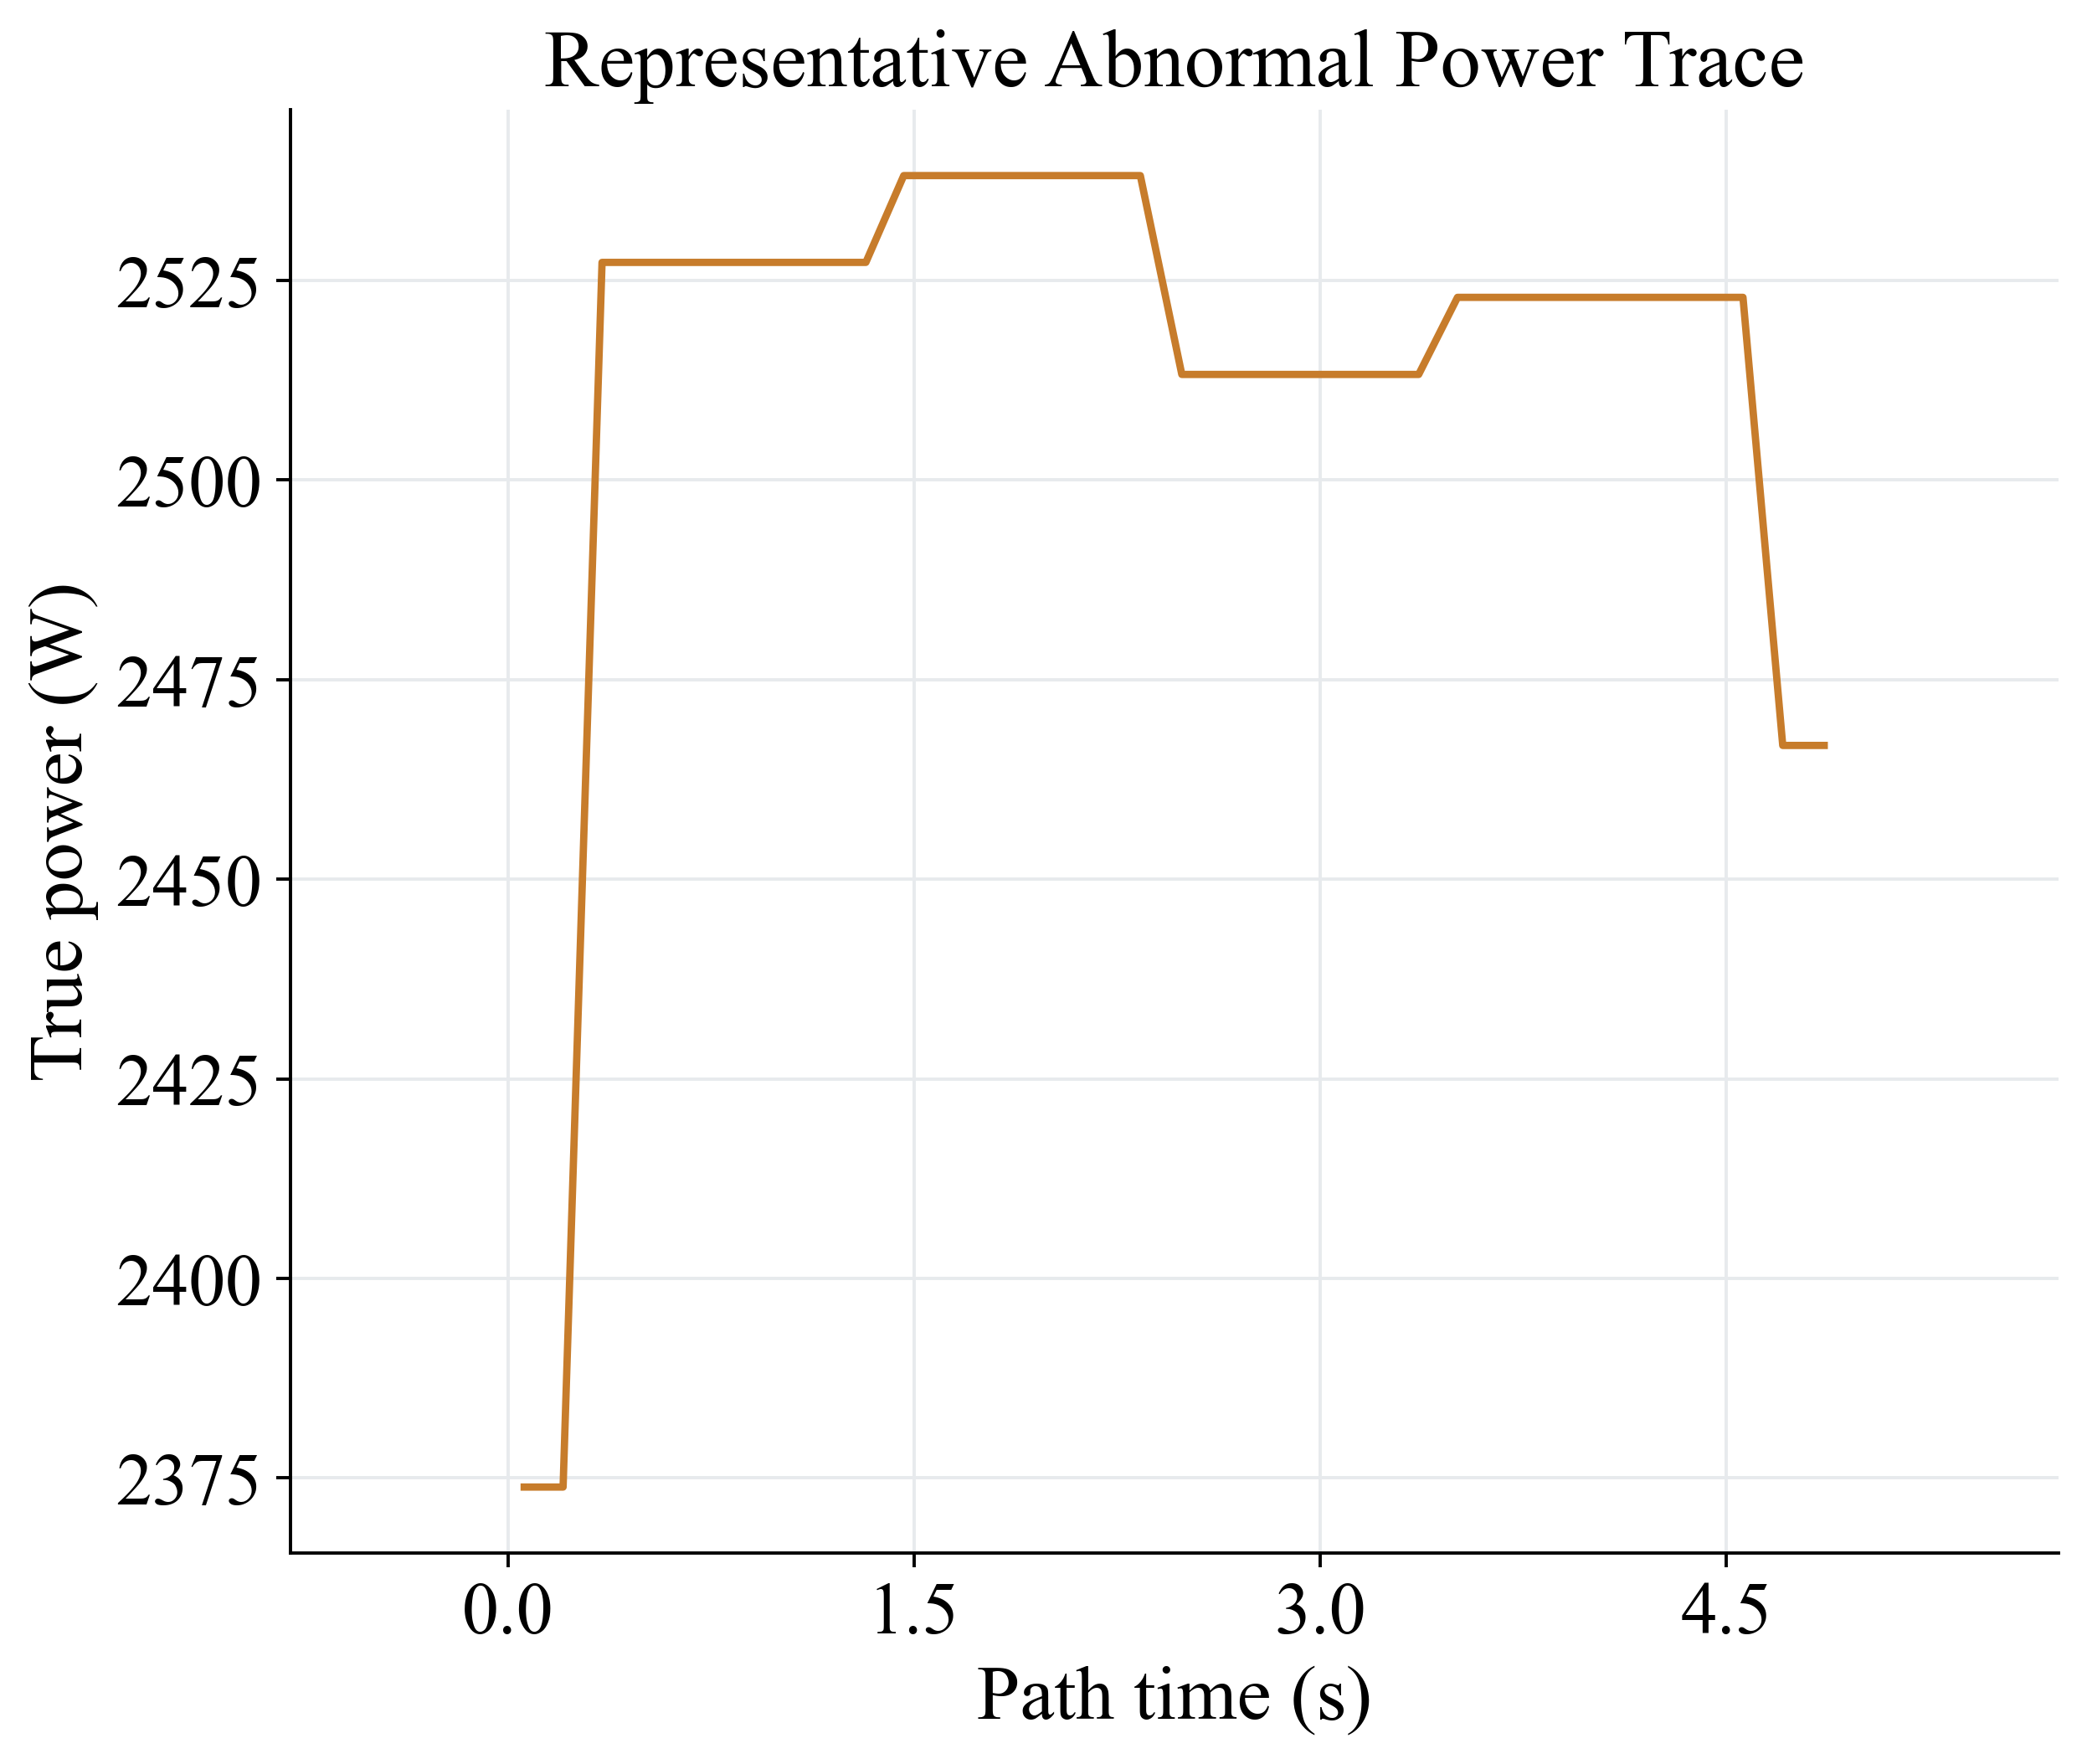

In [30]:
trajectory = representative[1]
fig, ax = figure_subplots(1, 1, span="double")
ax.plot(
    trajectory["time"], trajectory["signal"],
    linewidth=1.8, color=PALETTE["validation"],
)
ax.set_xlabel("Path time (s)")
ax.set_ylabel("True power (W)")
ax.set_title(f"Representative {state_names[1]} Power Trace")
ax.margins(x=0.18)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="lower"))
ax.grid(color=PALETTE["grid"])
_ = save_show_figure(
    fig, FIGURES / "01_representative_abnormal_signal.png", span="double"
)


The abnormal example uses the same deterministic selection rule as the normal example, preserving comparability without implying population-level separation.

## Representative tool-defect power trace

What temporal behavior is visible in the variance-median tool-defect development path?

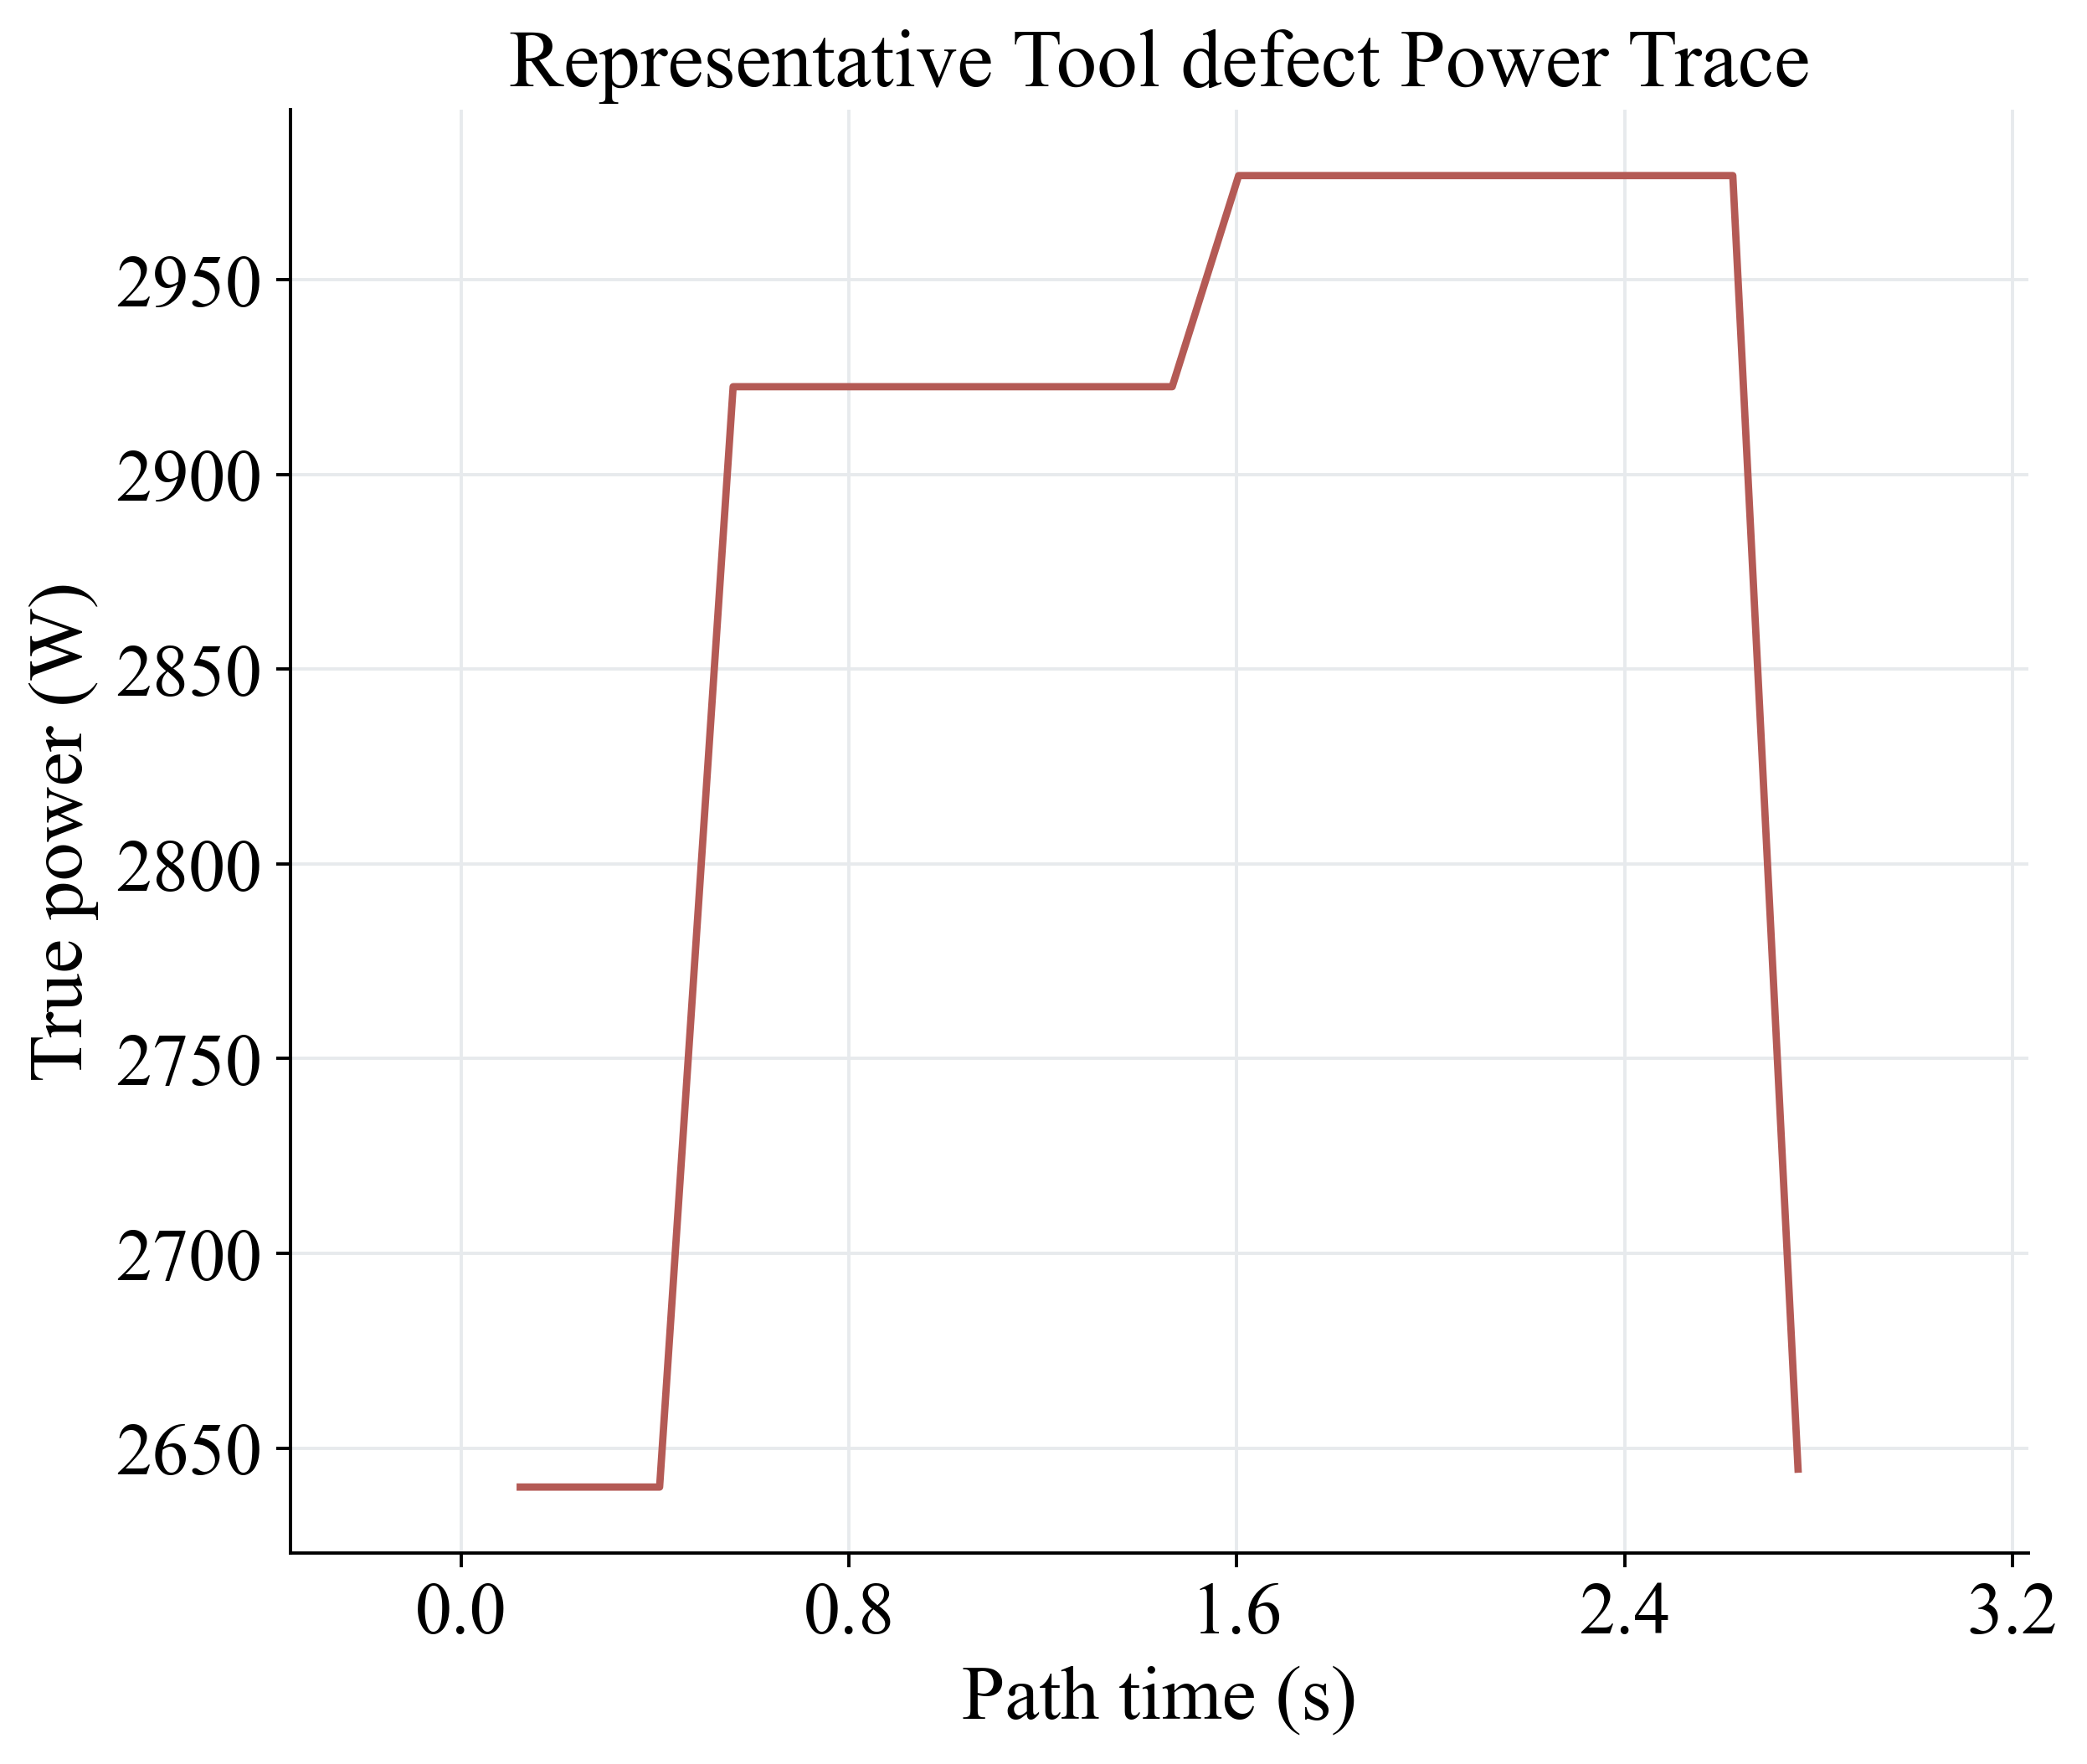

In [31]:
trajectory = representative[2]
fig, ax = figure_subplots(1, 1, span="double")
ax.plot(
    trajectory["time"], trajectory["signal"],
    linewidth=1.8, color=PALETTE["error"],
)
ax.set_xlabel("Path time (s)")
ax.set_ylabel("True power (W)")
ax.set_title(f"Representative {state_names[2]} Power Trace")
ax.margins(x=0.18)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="lower"))
ax.grid(color=PALETTE["grid"])
_ = save_show_figure(
    fig, FIGURES / "01_representative_tool_defect_signal.png", span="double"
)


The three state-specific canvases are descriptive raw-power evidence. The `watt` channel is used because its within-path variation is informative at the acquisition scale; the figures do not establish that power alone identifies intervention risk.

## Process-setting distributions

Do the development and external machines occupy the same ranges of recorded spindle, feed, depth, and width settings?

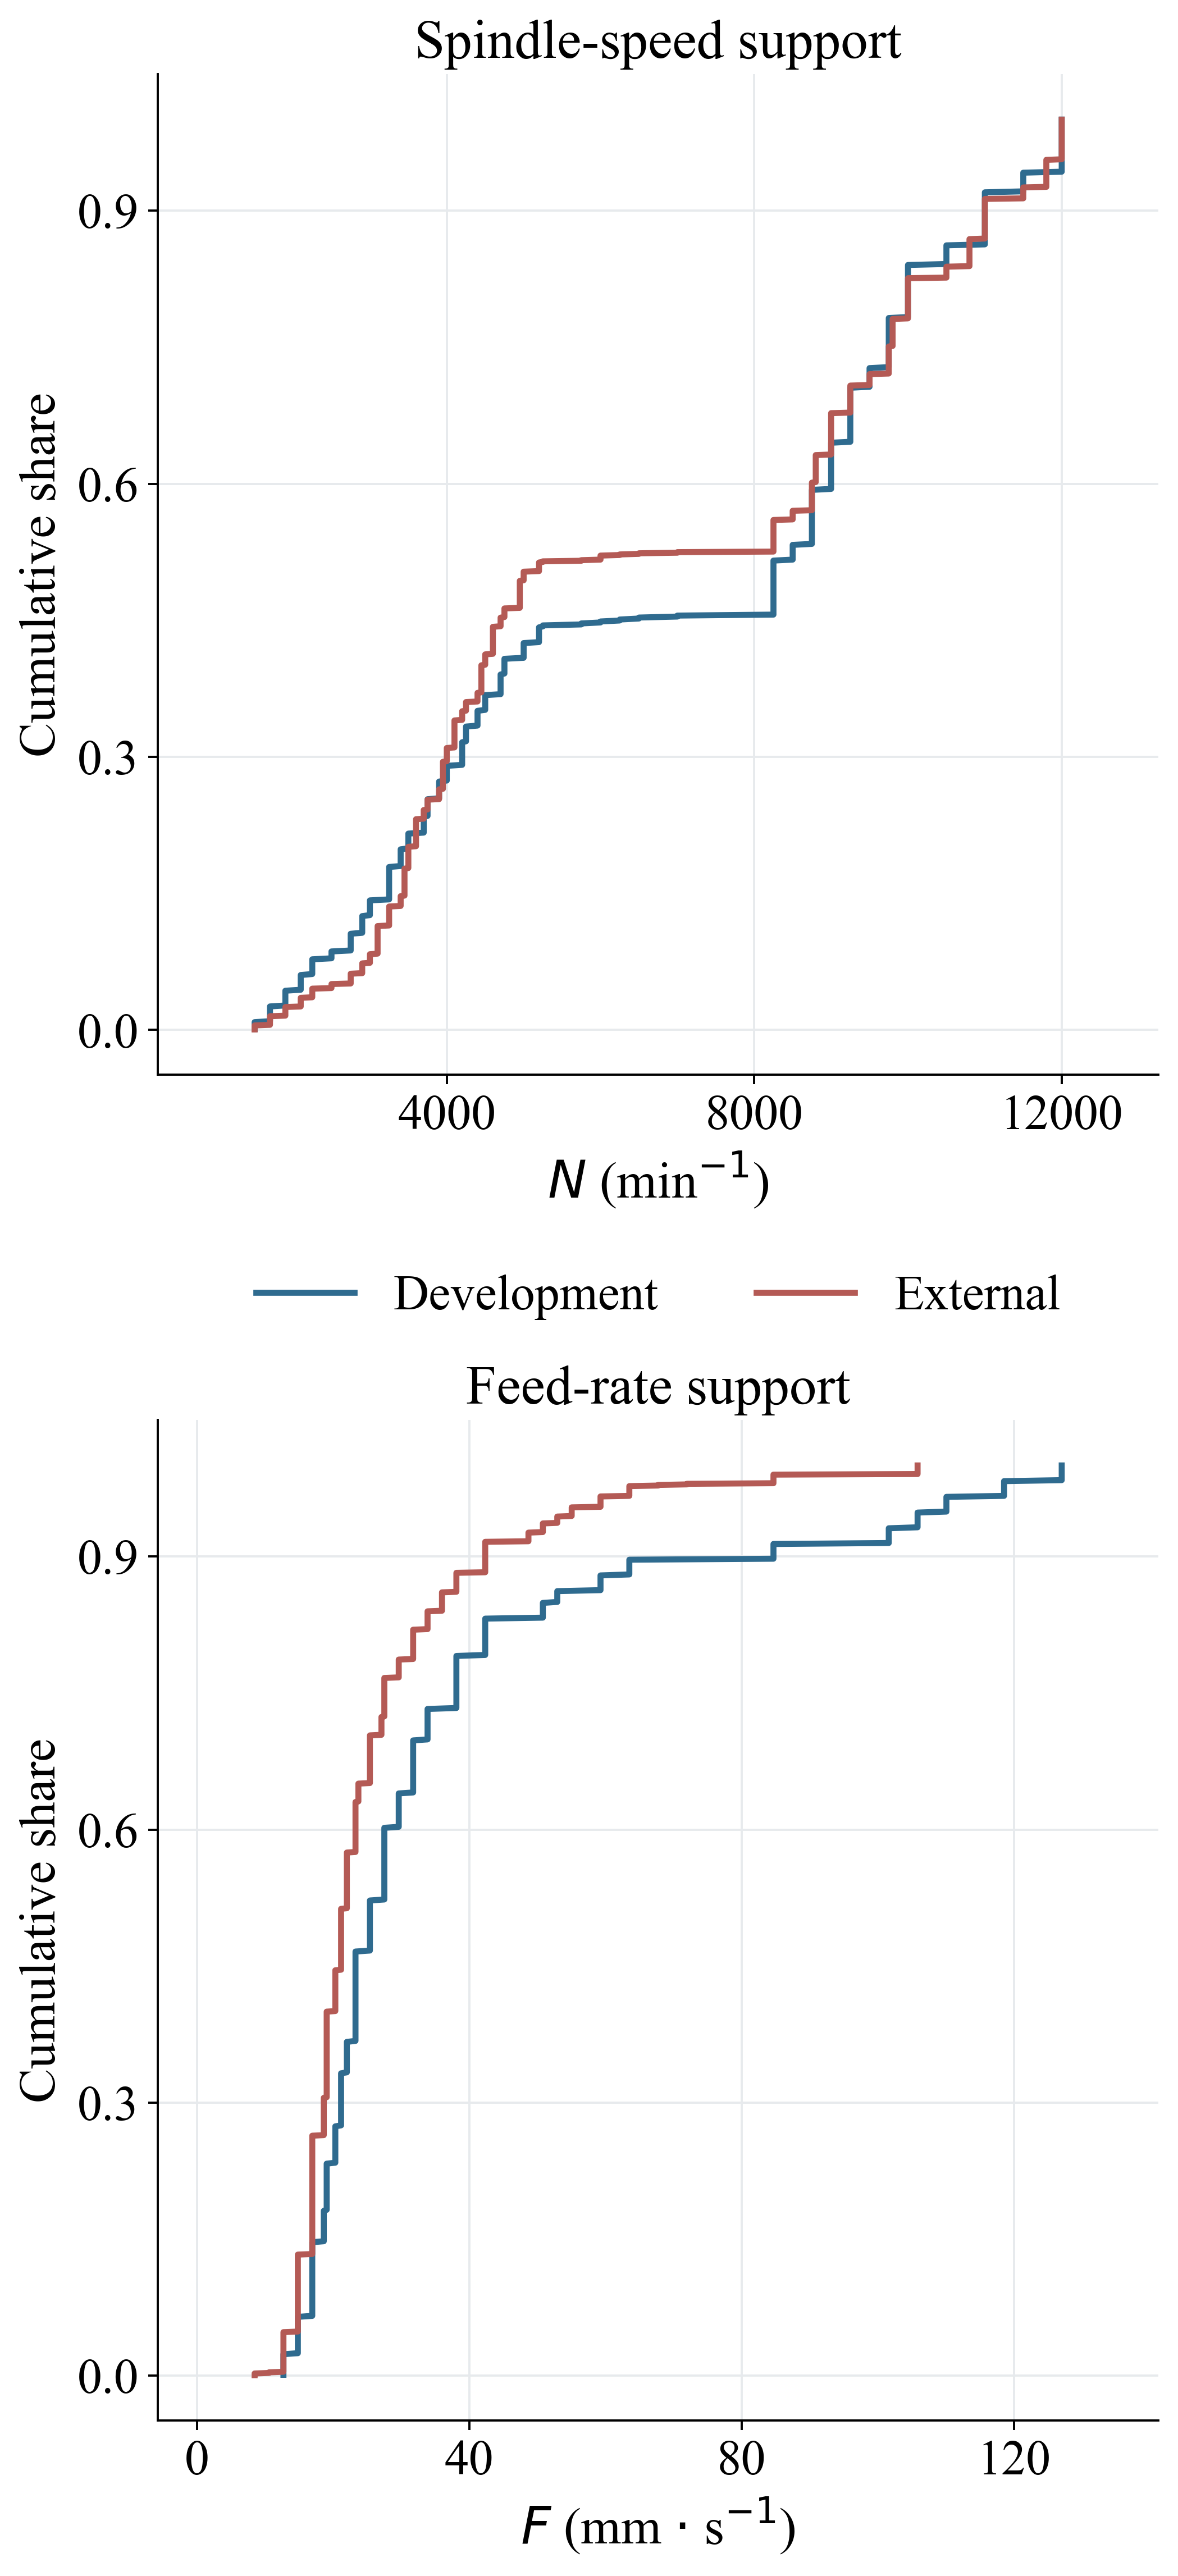

In [32]:
def plot_setting_support(parameter_specs, output_name):
    """Compare two process-setting distributions across acquisition domains."""
    fig, axes = figure_subplots(
        2, 1, span="double", legend_items=2, sharey=True
    )
    for axis, (column, title, x_label) in zip(axes, parameter_specs):
        for machine_id, label, color in [
            ("imi_vmx30ui", "Development", PALETTE["lab"]),
            ("imi_vm20i", "External", PALETTE["external"]),
        ]:
            values = pd.to_numeric(
                path_index.loc[path_index["machine_id"].eq(machine_id), column],
                errors="coerce",
            ).dropna()
            x, y = ecdf(values)
            axis.plot(x, y, linewidth=2.2, color=color, label=label)
        axis.set_xlabel(x_label)
        axis.set_title(title)
        axis.xaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
        axis.margins(x=0.12)
        axis.yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
        axis.grid(color=PALETTE["grid"])
    for axis in axes:
        axis.set_ylabel("Cumulative share")
    legend_below(axes[0], ncol=2)
    return save_show_figure(fig, FIGURES / output_name, span="double")
_ = plot_setting_support(
    [("N", "Spindle-speed support", r"$N$ (min$^{-1}$)"),
     ("F", "Feed-rate support", r"$F$ (mm $\cdot$ s$^{-1}$)")],
    "01_spindle_feed_support.png",
)


Spindle and feed support reveal whether the external machine is evaluated inside or outside the development operating envelope; no outcome labels enter this comparison.

### Cutting-geometry support

Are axial depth and radial width settings comparable between the development and external-machine domains?

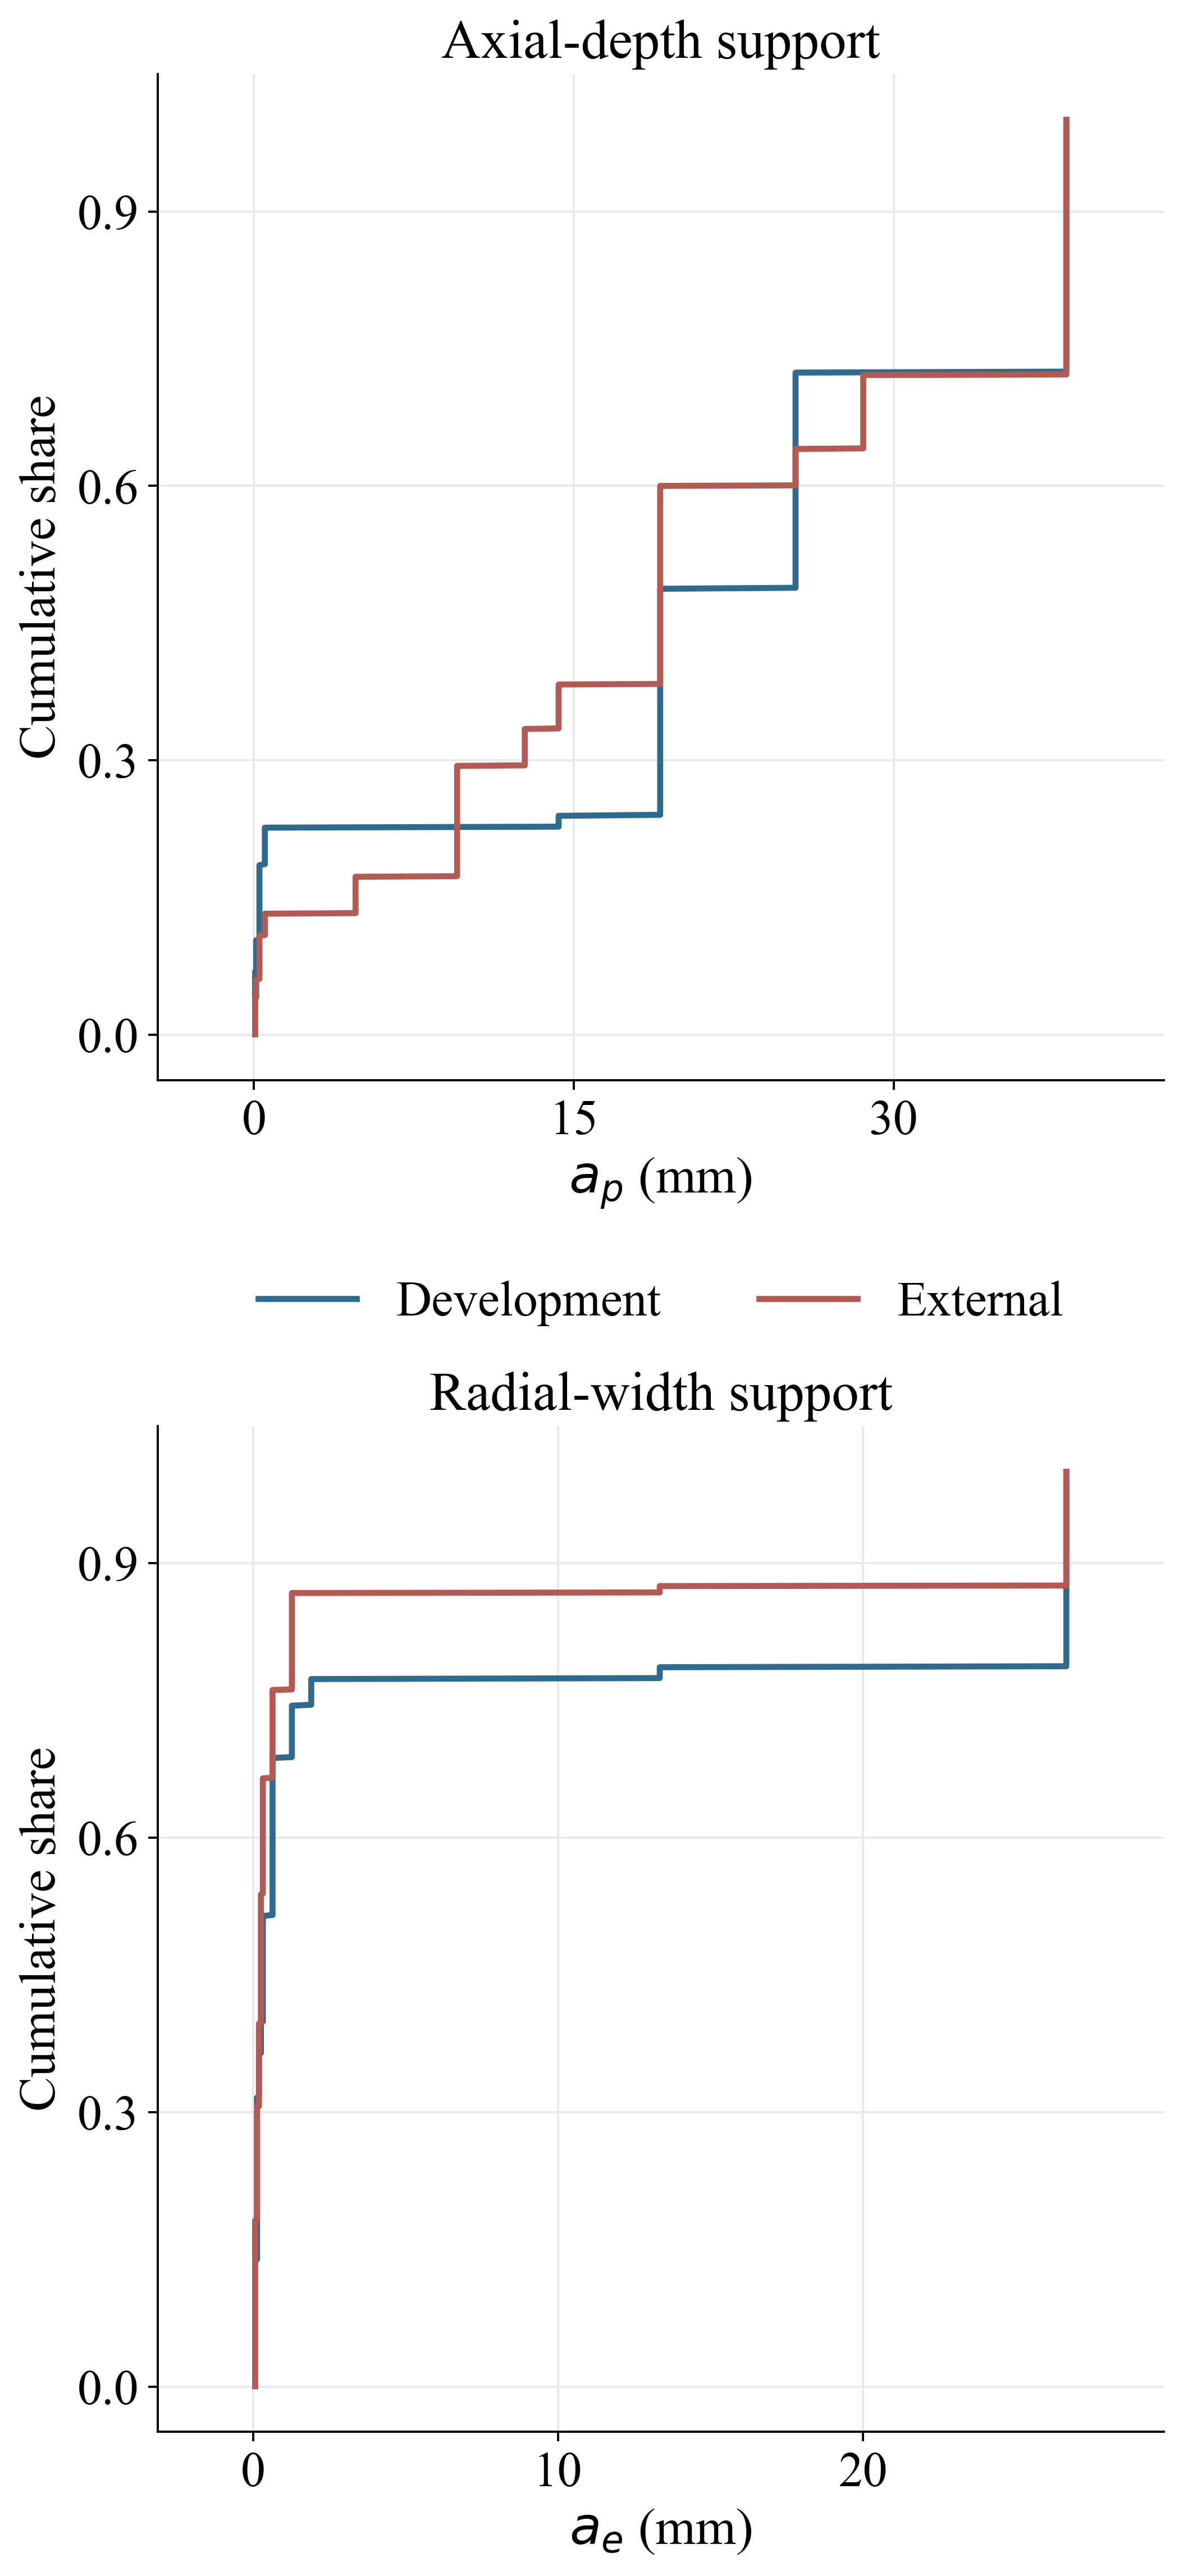

In [33]:
_ = plot_setting_support(
    [("ap", "Axial-depth support", r"$a_p$ (mm)"),
     ("ae", "Radial-width support", r"$a_e$ (mm)")],
    "01_depth_width_support.png",
)


Depth and width support complete the process-envelope audit. Differences are treated as measurable domain shift rather than hidden under a pooled descriptive summary.

### Categorical process composition

Which workpiece and tool categories are represented in each domain, including rare categories that may define failure modes?

In [34]:
category_rows = []
for machine_id in ["imi_vmx30ui", "imi_vm20i"]:
    domain_frame = path_index[path_index["machine_id"].eq(machine_id)]
    for variable in ["Workpiece", "Tool", "direction"]:
        values = domain_frame[variable].astype("string").fillna("Missing")
        counts = values.value_counts(dropna=False)
        for category, count in counts.items():
            category_rows.append(
                {
                    "machine_id": machine_id,
                    "domain_role": domain_names[machine_id],
                    "variable": variable,
                    "category": str(category),
                    "n": int(count),
                    "within_domain_percent": 100.0 * count / len(domain_frame),
                }
            )
categorical_composition = pd.DataFrame(category_rows)
display_grouped_tables(
    categorical_composition,
    identifier_columns=["machine_id", "domain_role", "variable", "category"],
    column_groups={"Observed categorical support": ["n", "within_domain_percent"]},
    digits=3,
)


#### Observed categorical support

,machine_id,domain_role,variable,category,n,within_domain_percent
0,imi_vmx30ui,Development,Workpiece,AISI 1018,425,45.847
1,imi_vmx30ui,Development,Workpiece,AA 6061,286,30.852
2,imi_vmx30ui,Development,Workpiece,AISI 4140,216,23.301
3,imi_vmx30ui,Development,Tool,E,283,30.529
4,imi_vmx30ui,Development,Tool,D,142,15.318
5,imi_vmx30ui,Development,Tool,C2,128,13.808
6,imi_vmx30ui,Development,Tool,A,128,13.808
7,imi_vmx30ui,Development,Tool,E*,76,8.198
8,imi_vmx30ui,Development,Tool,B,64,6.904
9,imi_vmx30ui,Development,Tool,F2,64,6.904


All observed categories are retained in the table; rare tools are not suppressed. Notebook 02 will encode categories from the training vocabulary only and will quantify missing/unknown support explicitly.

## Group-safe split design

How are complete independent experiments allocated to training, selection/calibration, locked internal evaluation, and cross-machine evaluation without entity overlap?

In [35]:
DEVELOPMENT_SPLITS = {
    "train": {
        "dataset2", "dataset4", "dataset6", "dataset8", "dataset11",
        "dataset12", "dataset14", "dataset15", "dataset16", "dataset17", "dataset18",
    },
    "validation": {"dataset5", "dataset7", "dataset19"},
    "internal_test": {"dataset1", "dataset3", "dataset9", "dataset10", "dataset13"},
}
split_lookup = {
    experiment_id: split_name
    for split_name, experiment_ids in DEVELOPMENT_SPLITS.items()
    for experiment_id in experiment_ids
}
split_assignments = path_index[[
    "cutting_path_id", "machine_id", "experiment_id", "start", "end",
    "StateLabel", "InterventionRequired",
]].copy()
split_assignments["split"] = split_assignments["experiment_id"].map(split_lookup)
split_assignments.loc[
    split_assignments["machine_id"].eq("imi_vm20i"), "split"
] = "external"
assert split_assignments["split"].notna().all()
assert split_assignments.groupby(["machine_id", "experiment_id"])["split"].nunique().max() == 1
split_summary = (
    split_assignments.groupby("split", as_index=False)
    .agg(
        observations=("cutting_path_id", "size"),
        independent_experiments=("experiment_id", "nunique"),
        positive_bearing_experiments=(
            "experiment_id",
            lambda values: split_assignments.loc[
                values.index
            ].groupby("experiment_id")["InterventionRequired"].max().sum(),
        ),
        intervention_n=("InterventionRequired", "sum"),
        intervention_rate=("InterventionRequired", "mean"),
        observed_start_s=("start", "min"),
        observed_end_s=("end", "max"),
    )
)


In [36]:
prevalence_ranges = (
    split_assignments.groupby(["split", "experiment_id"], as_index=False)
    .agg(experiment_intervention_rate=("InterventionRequired", "mean"))
    .groupby("split", as_index=False)
    .agg(
        minimum_experiment_prevalence=("experiment_intervention_rate", "min"),
        maximum_experiment_prevalence=("experiment_intervention_rate", "max"),
    )
)
split_summary = split_summary.merge(prevalence_ranges, on="split", validate="one_to_one")
split_summary["role"] = split_summary["split"].map(
    {
        "train": "Model development",
        "validation": "Selection and calibration",
        "internal_test": "Locked internal evaluation",
        "external": "Cross-machine evaluation",
    }
)
split_order = ["train", "validation", "internal_test", "external"]
split_summary["split"] = pd.Categorical(split_summary["split"], split_order, ordered=True)
split_summary = split_summary.sort_values("split").reset_index(drop=True)
split_summary["split"] = split_summary["split"].astype("string")
display_grouped_tables(
    split_summary,
    identifier_columns=["split", "role"],
    column_groups={
        "Independent allocation": [
            "observations", "independent_experiments", "positive_bearing_experiments",
        ],
        "Target balance": [
            "intervention_n", "intervention_rate",
            "minimum_experiment_prevalence", "maximum_experiment_prevalence",
        ],
        "Observed machine-time range": ["observed_start_s", "observed_end_s"],
    },
    digits=4,
)


#### Independent allocation

,split,role,observations,independent_experiments,positive_bearing_experiments
0,train,Model development,563,11,5
1,validation,Selection and calibration,192,3,1
2,internal_test,Locked internal evaluation,172,5,3
3,external,Cross-machine evaluation,1585,37,22


#### Target balance

,split,role,intervention_n,intervention_rate,minimum_experiment_prevalence,maximum_experiment_prevalence
0,train,Model development,127,0.2256,0.0000,1.0000
1,validation,Selection and calibration,64,0.3333,0.0000,1.0000
2,internal_test,Locked internal evaluation,32,0.1860,0.0000,1.0000
3,external,Cross-machine evaluation,412,0.2599,0.0000,1.0000


#### Observed machine-time range

,split,role,observed_start_s,observed_end_s
0,train,Model development,9.1310,517.0130
1,validation,Selection and calibration,10.2190,591.1040
2,internal_test,Locked internal evaluation,0.0000,449.6850
3,external,Cross-machine evaluation,7.4880,592.2990


Every independent experiment belongs to exactly one role. The table exposes the number of positive-bearing experiments and the prevalence range, avoiding the misleading assumption that aggregate path balance implies balanced independent groups. External labels have been descriptively inspected, so this split is correctly described as unused for fitting/selection rather than unseen.

In [37]:
path_export = path_index.drop(columns=["previous_end"]).copy()
path_export.to_parquet(PROCESSED / "cutting_path_index.parquet", index=False)
split_assignments.to_parquet(PROCESSED / "split_assignments.parquet", index=False)
sample_characterization.to_csv(TABLES / "sample_characterization.csv", index=False)
target_distribution.to_csv(TABLES / "target_distribution.csv", index=False)
experiment_registry.to_csv(TABLES / "experiment_registry.csv", index=False)
quality_summary.to_csv(TABLES / "data_quality_summary.csv", index=False)
semantic_coverage.to_csv(TABLES / "semantic_coverage.csv", index=False)
structural_availability.to_csv(TABLES / "structural_feature_availability.csv", index=False)
categorical_composition.to_csv(TABLES / "categorical_composition.csv", index=False)
split_summary.to_csv(TABLES / "split_summary.csv", index=False)
mtc_audit.to_csv(TABLES / "experiment_audit.csv", index=False)
feature_inventory.to_csv(TABLES / "mtc_feature_inventory.csv", index=False)
semantic_metadata.to_csv(TABLES / "mtc_semantic_metadata.csv", index=False)
_ = gc.collect()


## Summary

The study population comprises nested cutting paths from distinct development and external-machine experiments with nontrivial target, temporal, sampling, feature-availability, semantic, and process-setting heterogeneity. Original interval integrity and raw completeness have been audited, while structural absence is explicitly separated from raw-cell missingness. The fixed split design prevents experiment overlap and reserves validation for selection/calibration and held-out domains for evaluation only. The path and split indices are used in Notebook 02; learned transformations are restricted to the development-training partition.